# WP3 — Africa Multi‑Hazard Prioritisation Tool (Country + Regional)

This notebook turns the **intermediate long table** (country × hazard × indicator) into:

- **Dimension scores** (5 dimensions) per **country × hazard**
- **Hazard scores & rankings** per **country**
- **Regional hazard prioritisation** per **region** (both **population‑weighted** and **unweighted**)
- **Explainability**: exactly *which indicators* contributed to each score, and how sensitive results are to key rules

---

## Inputs (edit only if your folder structure changes)

- Indicators long table: `C:\pipelines\sewa-multihazar\data\intermediate\wp3_country_indicators_long.csv`
- Population (World Bank WDI): `C:\pipelines\sewa-multihazar\data\raw\population\API_SP.POP.TOTL_DS2_en_csv_v2_34.zip`

> **Population definition (WDI SP.POP.TOTL):** de‑facto population, **mid‑year estimates**  
> Source: World Bank WDI metadata glossary (SP.POP.TOTL)

---

## What this notebook is (and is not)

✅ **It is** a transparent, scenario‑driven prioritisation tool that lets you compare:
- Overlap handling (e.g., EM‑DAT vs DesInventar on the same construct)
- Inclusion of hazard‑agnostic indicators **per hazard**
- Population‑weighted vs unweighted regional aggregation

❌ **It is not** a dataset extraction notebook. Extraction happens upstream (WP3_01…WP3_06 notebooks).

---


## Normalisation

Different indicators come in different units (events/year, USD/person, index 0–10, etc.).  
To combine them with **equal weights**, we first convert every indicator to a **common 0–1 scale**.

### We use *rank / percentile normalisation*

For each indicator **separately**, we rank countries from lowest to highest value.

- Let **N** be the number of countries with data for that indicator.
- Let **rank(x)** be the rank of a country’s value (ties get the average rank).
- The **percentile score** is:

\[
score = \frac{rank(x)-1}{N-1}
\]

Interpretation:
- `score = 0.0` → among the **lowest** values in Africa for that indicator  
- `score = 1.0` → among the **highest** values in Africa for that indicator  

Because we define **“higher = worse”** for prioritisation, we keep the percentile as‑is.  
(If an indicator were “higher = better”, we would invert it: `1 - score`.)

### Why rank/percentile?

- It is **robust to outliers** (one extreme value does not crush everyone else).
- It is easy to explain to non‑technical users: “this country is in the top X% for this indicator”.
- It fits the goal: **ranking / prioritisation**, not absolute calibration.

Trade‑off:
- It is **relative**. A difference between 0.90 and 0.95 does *not* mean “twice as bad”.

References (background reading):
- OECD/JRC Handbook on Constructing Composite Indicators 
- JRC “Tools for Composite Indicators Building” 

---


In [1]:
from __future__ import annotations

import os
import re
import zipfile
from dataclasses import dataclass
from typing import Dict, List, Literal, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


## 1) Control panel (paths, switches, weights)

Everything important is controlled here.


In [2]:
# =========================
# PATHS (edit if needed)
# =========================
PATH_LONG = r"C:\pipelines\sewa-multihazar\data\intermediate\wp3_country_indicators_long.csv"
PATH_POP_ZIP = r"C:\pipelines\sewa-multihazar\data\raw\population\API_SP.POP.TOTL_DS2_en_csv_v2_34.zip"

# Fallbacks for non-Windows environments (e.g., CI / container runs)
if not os.path.exists(PATH_LONG):
    for cand in [
        os.path.join("data", "intermediate", "wp3_country_indicators_long.csv"),
        os.path.join("data", "processed", "wp3_country_indicators_long.csv"),
        "/mnt/data/wp3_country_indicators_long.csv",
    ]:
        if os.path.exists(cand):
            PATH_LONG = cand
            break

if not os.path.exists(PATH_POP_ZIP):
    for cand in [
        os.path.join("data", "raw", "population", os.path.basename(PATH_POP_ZIP)),
        "/mnt/data/" + os.path.basename(PATH_POP_ZIP),
        "/mnt/data/API_SP.POP.TOTL_DS2_en_csv_v2_34.zip",
    ]:
        if os.path.exists(cand):
            PATH_POP_ZIP = cand
            break

# Where to write outputs
OUT_DIR = r"C:\pipelines\sewa-multihazar\data\output\wp3_prioritisation"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# =========================
# SCOPE
# =========================
HAZARDS = [
    "Drought",
    "Flash Flooding",
    "Riverine Flooding Continued & Cluster",
    "Heatwave",
    "Storm Surge",
    "Wind",
    "Thunderstorm",
    "Wildfires",
    "Dust",
]
DIMENSIONS = ["Prevalence", "Scale", "Impact", "Cascade impacts", "Future relevance"]

# =========================
# WEIGHTS (default = equal)
# Keep as explicit tables so you can edit later.
# =========================
DIM_WEIGHTS = {d: 1.0 for d in DIMENSIONS}  # equal weights by default

# Indicator weights are equal by default; you can override per hazard × dimension × indicator_id later if needed.
# Example override:
# INDICATOR_WEIGHTS = {("Drought", "Impact", "EM-DAT.DEATHS_PER100K_2000_2024"): 2.0}
INDICATOR_WEIGHTS = {}

# =========================
# OVERLAP RULES
# =========================
OVERLAP_THRESHOLD = 0.25   # apply arbitration if overlap rate ≥ 25%
OVERLAP_MODE_DEFAULT = "M0_keep_all"  # "M0_keep_all" or "M1_construct_arbitration"

# Construct arbitration method
ARBITRATION_METHOD = "proxy_completeness"  # or "prefer_emdat" (simple deterministic)

# Economic loss construct rule 
# Prefer EM-DAT adjusted USD/person if available, else DesInventar USD/person
ECON_LOSS_RULE = "prefer_emdat_adj_per_person"

# =========================
# HAZARD-AGNOSTIC SWITCHES (PER HAZARD)
# Defaults = your approved recommendation
#   - INFORM lack of coping -> Cascade impacts (include)
#   - WRI adaptive capacity -> Future relevance (include)
#   - INFORMCC overall risk index -> Future relevance (gap-fill)
# You can override hazard-by-hazard below.
# =========================
AgnosticMode = Literal["exclude", "include", "gapfill_only"]

AGNOSTIC_DEFAULTS = {
    "INFORM.DIM.LACK_COPING": ("Cascade impacts", "include"),
    "WRI.A": ("Future relevance", "include"),
    "INFORMCC.RISK_INDEX.2050.pessimistic": ("Future relevance", "gapfill_only"),
}

# Per-hazard override table (start from defaults for all hazards)
AGNOSTIC_PER_HAZARD: Dict[str, Dict[str, AgnosticMode]] = {
    h: {k: v[1] for k, v in AGNOSTIC_DEFAULTS.items()}  # type: ignore
    for h in HAZARDS
}

# =========================
# INDICATOR LIST
# =========================
# Start with a recommended scoring set.
# Everything not in the scoring set becomes QA-only by default.
SCORING_INDICATORS = {
    # Prevalence
    "EM-DAT.EVENTS_PER_YEAR_2000_2024",
    "DESINVENTAR.EVENTS_PER_YEAR_2000_2024",
    "TH.UF_LEVEL", "TH.FL_LEVEL", "TH.CF_LEVEL", "TH.CY_LEVEL", "TH.TS_LEVEL", "TH.EH_LEVEL", "TH.WF_LEVEL", "TH.DG_LEVEL",

    # Scale
    "EM-DAT.ADMIN_SPREAD_MEAN_ADM2_2000_2024",
    "DESINVENTAR.ADMIN_SPREAD_MEAN_ADM2_2000_2024",
    "EM-DAT.DURATION_MEAN_DAYS_2000_2024",
    "DESINVENTAR.DURATION_MEAN_DAYS_2000_2024",
    "EM-DAT.MAGNITUDE_MEAN_2000_2024",
    "DESINVENTAR.MAGNITUDE_MEAN_2000_2024",
    "INFORM.HAZEX.DROUGHT",
    "INFORM.HAZEX.RIVER_FLOOD",
    "INFORM.HAZEX.COASTAL_FLOOD",
    "INFORM.HAZEX.TROPICAL_CYCLONE",
    "WRI.EI_06", "WRI.EI_04", "WRI.EI_03", "WRI.EI_05",

    # Impact (per-capita / rate based)
    "EM-DAT.DEATHS_PER100K_2000_2024",
    "DESINVENTAR.DEATHS_PER100K_2000_2024",
    "EM-DAT.AFFECTED_PER100K_2000_2024",
    "DESINVENTAR.AFFECTED_PER100K_2000_2024",
    "EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA_2000_2024",
    "DESINVENTAR.LOSS_USD_PER_CAPITA_2000_2024",

    # Cascade impacts
    "IDMC.DISPLACEMENTS_PER100K_2000_2024_POPREF",  # prefer per-capita displacement
    "INFORM.DIM.LACK_COPING",  # hazard-agnostic 

    # Future relevance
    "INFORMCC.CHG_HAZEX.FLOOD.2050.pessimistic",
    "INFORMCC.CHG_HAZEX.COASTAL_FLOOD.2050.pessimistic",
    "INFORMCC.CHG_HAZEX.DROUGHT.2050.pessimistic",
#    "WRI.A",  # hazard-agnostic
    "INFORMCC.RISK_INDEX.2050.pessimistic",  # hazard-agnostic gap-fill
}

QA_ONLY_INDICATORS = {
    # explicitly QA-only (kept for transparency)
    "EM-DAT.EVENTS_TOTAL_2000_2024",
    "DESINVENTAR.EVENTS_TOTAL_2000_2024",
    "EM-DAT.DEATHS_SUM_2000_2024",
    "DESINVENTAR.DEATHS_SUM_2000_2024",
    "EM-DAT.AFFECTED_SUM_2000_2024",
    "DESINVENTAR.AFFECTED_SUM_2000_2024",
    "EM-DAT.DAMAGE_ADJ_USD_SUM_2000_2024",
    "DESINVENTAR.LOSS_USD_SUM_2000_2024",
    "DESINVENTAR.EVACUATED_SUM_2000_2024",
    "DESINVENTAR.RELOCATED_SUM_2000_2024",
    "DESINVENTAR.AFFECTED_HOUSES_SUM_2000_2024",
    "DESINVENTAR.DESTROYED_HOUSES_SUM_2000_2024",
    "IDMC.DISPLACEMENTS_SUM",
    "INFORM.DIM.HAZARD_EXPOSURE",
    "WRI.E",
}

DEFAULT_SCENARIO = "S_main"

SCENARIOS = {
    # Main (your approved default)
    "S_main": {
        "overlap_mode": OVERLAP_MODE_DEFAULT,
        "include_agnostic": True,    # controls whether we replicate hazard-agnostic rows (still per-hazard switches)
    },
    # Sensitivities
    "S_noAgnostic": {"overlap_mode": OVERLAP_MODE_DEFAULT, "include_agnostic": False},
    "S_gapFillOnly": {"overlap_mode": OVERLAP_MODE_DEFAULT, "include_agnostic": True, "agnostic_force_gapfill": True},
    "S_futureHazOnly": {"overlap_mode": OVERLAP_MODE_DEFAULT, "include_agnostic": True, "future_hazard_only": True},
    "S_overlapArbitration": {"overlap_mode": "M1_construct_arbitration", "include_agnostic": True},
}

print("Control panel loaded. Default scenario:", DEFAULT_SCENARIO)


Control panel loaded. Default scenario: S_main


In [3]:
# --- Presence rules for exposure gating (Strategy 1) ---
PRESENCE_RULES = {
    "Drought": [
        ("TH.DG_LEVEL", "th_level", {"min_level": 2}),
        ("INFORM.HAZEX.DROUGHT", "gt0", {}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Flash Flooding": [
        ("TH.UF_LEVEL", "th_level", {"min_level": 2}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Riverine Flooding Continued & Cluster": [
        ("TH.FL_LEVEL", "th_level", {"min_level": 2}),
        ("INFORM.HAZEX.RIVER_FLOOD", "gt0", {}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Heatwave": [
        ("TH.EH_LEVEL", "th_level", {"min_level": 2}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Storm Surge": [
        # IMPORTANT: we intentionally avoid WRI.EI_03 here to prevent tiny-noise passing the gate inland.
        ("TH.CF_LEVEL", "th_level", {"min_level": 2}),
        ("INFORM.HAZEX.COASTAL_FLOOD", "gt0", {}),
        ("INFORMCC.CHG_HAZEX.COASTAL_FLOOD.2050.pessimistic", "gt0", {}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Wind": [
        ("TH.CY_LEVEL", "th_level", {"min_level": 2}),
        ("INFORM.HAZEX.TROPICAL_CYCLONE", "gt0", {}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Thunderstorm": [
        ("TH.TS_LEVEL", "th_level", {"min_level": 2}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Wildfires": [
        ("TH.WF_LEVEL", "th_level", {"min_level": 2}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
    "Dust": [
        # Dust protection: ThinkHazard signal keeps it alive even when event reporting is sparse.
        ("TH.DG_LEVEL", "th_level", {"min_level": 2}),
        ("EM-DAT.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
        ("DESINVENTAR.EVENTS_PER_YEAR_2000_2024", "gt0", {}),
    ],
}

## 2) Helper functions (loading, QA, normalisation, scoring, exporting)

These functions implement the methodology in a **modular** way so you can change rules later without rewriting the notebook.


In [4]:
def load_long_table(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Indicators file not found: {path}")
    df = pd.read_csv(path)

    # Column harmonisation (upstream extractors may name things slightly differently)
    rename_map = {}
    if "country" not in df.columns and "country_name" in df.columns:
        rename_map["country_name"] = "country"
    if rename_map:
        df = df.rename(columns=rename_map)

    # basic hygiene
    for col in ["iso3","country","region","hazard","dimension","source","indicator_id"]:
        if col in df.columns:
            df[col] = (
                df[col].astype(str)
                .str.replace("\u00A0", " ", regex=False)   # NBSP -> space
                .str.strip()
                .str.replace(r"\s+", " ", regex=True)      # collapse multiple spaces
            )    
    return df


def load_wdi_population_from_zip(path_zip: str, year: int = 2024) -> pd.DataFrame:
    if not os.path.exists(path_zip):
        raise FileNotFoundError(f"Population zip not found: {path_zip}")
    with zipfile.ZipFile(path_zip, "r") as z:
        # pick the main API_*.csv (not Metadata_*)
        candidates = [n for n in z.namelist() if n.lower().endswith(".csv") and "metadata" not in n.lower()]
        if not candidates:
            raise FileNotFoundError("No data CSV found inside zip (excluding Metadata files).")
        name = candidates[0]
        with z.open(name) as f:
            pop = pd.read_csv(f, skiprows=4)
    needed = {"Country Code", str(year)}
    if not needed.issubset(pop.columns):
        raise ValueError(f"Population CSV missing expected columns: {needed}. Found: {pop.columns.tolist()[:20]} ...")
    out = pop[["Country Code", str(year)]].rename(columns={"Country Code": "iso3", str(year): f"pop_{year}"})
    out["iso3"] = out["iso3"].astype(str).str.strip()
    out[f"pop_{year}"] = pd.to_numeric(out[f"pop_{year}"], errors="coerce")
    return out

def assert_required_columns(df: pd.DataFrame, required: List[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Found columns: {df.columns.tolist()}")

def scope_filter(df: pd.DataFrame) -> pd.DataFrame:
    # Keep only the 9 hazards + All Hazards
    keep = set(HAZARDS + ["All Hazards"])
    df = df[df["hazard"].isin(keep)].copy()
    # If regions exist, we keep them (assumed already in scope)
    return df

def scope_filter_loud(df: pd.DataFrame, hazards: list[str]) -> pd.DataFrame:
    keep = set(hazards + ["All Hazards"])
    # hygiene: strip hazards in case trailing spaces exist
    df = df.copy()
    df["hazard"] = df["hazard"].astype(str).str.strip()

    present = set(df["hazard"].dropna().unique())
    removed = sorted(present - keep)
    missing_expected = sorted(set(hazards) - present)

    if removed:
        counts = df.loc[df["hazard"].isin(removed), "hazard"].value_counts()
        print("[SCOPE][DROP] Hazards present in data but NOT in HAZARDS list (will be dropped):")
        print(counts.to_string())
    else:
        print("[SCOPE] No hazards would be dropped by scope filter.")

    if missing_expected:
        print("\n[SCOPE][MISSING] Hazards expected (in HAZARDS list) but NOT present in data:")
        print(missing_expected)

    out = df[df["hazard"].isin(keep)].copy()
    print(f"\n[SCOPE] Rows before: {len(df):,} | after: {len(out):,} | dropped: {len(df)-len(out):,}")
    return out


def make_indicator_metadata(df: pd.DataFrame) -> pd.DataFrame:
    meta_cols = ["indicator_id", "indicator_name", "source", "dimension", "hazard", "unit_raw", "time_window"]
    existing = [c for c in meta_cols if c in df.columns]
    meta = df[existing].drop_duplicates().copy()
    meta["hazard_applicability"] = np.where(meta["hazard"].eq("All Hazards"), "hazard-agnostic", "hazard-specific")
    # Default direction: higher = worse
    meta["direction"] = "higher_is_worse"
    # Categorical flag (ThinkHazard 1–4)
    meta["is_categorical"] = meta["indicator_id"].str.startswith("TH.")
    return meta

def plot_coverage_heatmap(df: pd.DataFrame, title: str, outpath: Optional[str] = None) -> None:
    pivot = df.pivot_table(index="hazard", columns="dimension", values="iso3", aggfunc=pd.Series.nunique, fill_value=0)
    pivot = pivot.reindex(index=["All Hazards"] + HAZARDS, columns=DIMENSIONS, fill_value=0)
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(pivot.values)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, str(pivot.iloc[i, j]), ha="center", va="center", fontsize=8)
    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=200)
    plt.show()

def percentile_normalise(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    mask = s.notna()
    n = int(mask.sum())
    out = pd.Series(np.nan, index=series.index, dtype=float)

    if n <= 1:
        out[mask] = 0.5  # neutral when only one country has data
        return out

    ranks = s[mask].rank(method="average")  # 1..N
    out[mask] = (ranks - 1) / (n - 1)       # 0..1
    return out

import numpy as np
import pandas as pd
import re

# Indicators where 0 usually means "no exposure / no events / no impact" (structural zero)
ZERO_IS_ZERO_PATTERN = re.compile(
    r"(?:" 
    r"HAZEX\.|CHG_HAZEX\.|"          # hazard exposure indicators (INFORM / INFORMCC)
    r"EVENTS_|DEATHS_|AFFECTED_|"    # event/impact rates
    r"DISPLACEMENTS_|"              # IDMC displacement metrics
    r"USD_PER_CAPITA"               # loss per person
    r")"
)

TH_MAP = {1: 0.0, 2: 1/3, 3: 2/3, 4: 1.0}


def _percentile_norm_nonzero(s: pd.Series) -> pd.Series:
    """Percentile normalisation on non-zero values only (expects numeric series)."""
    out = pd.Series(np.nan, index=s.index, dtype=float)
    pos = s.notna() & (s > 0)
    if pos.sum() == 0:
        return out
    if pos.sum() == 1:
        out.loc[pos] = 1.0
        return out
    out.loc[pos] = s.loc[pos].rank(method="average", pct=True).astype(float)
    return out

def _percentile_norm_standard(s: pd.Series) -> pd.Series:
    """Standard percentile normalisation with neutral=0.5 for singletons."""
    out = pd.Series(np.nan, index=s.index, dtype=float)
    m = s.notna()
    if m.sum() == 0:
        return out
    if m.sum() == 1:
        out.loc[m] = 0.5
        return out
    out.loc[m] = s.loc[m].rank(method="average", pct=True).astype(float)
    return out

def apply_normalisation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalisation to [0,1] per indicator_id over UNIQUE iso3 values (robust to replication).
    For structural-zero indicators: 0 -> 0.0, and percentiles computed on strictly positive values only.
    """
    df = df.copy()
    df["value_raw"] = pd.to_numeric(df["value_raw"], errors="coerce")
    df["score_01"] = np.nan

    # 1) Categorical (ThinkHazard)
    is_cat = df.get("is_categorical", pd.Series(False, index=df.index)).fillna(False) | \
             df["indicator_id"].astype(str).str.startswith("TH.")
    if is_cat.any():
        vals = df.loc[is_cat, "value_raw"].round().astype("Int64")
        df.loc[is_cat, "score_01"] = vals.map(TH_MAP).astype(float)

    # 2) Continuous indicators
    cont = ~is_cat

    def norm_indicator(g: pd.DataFrame) -> pd.DataFrame:
        ind = str(g["indicator_id"].iloc[0])

        # representative iso3 value (robust to duplicates from replication/joins)
        iso_vals = (
            g[["iso3", "value_raw"]]
            .sort_values(["iso3"])
            .groupby("iso3", as_index=False)["value_raw"]
            .first()
        )
        v = iso_vals["value_raw"]

        score = pd.Series(np.nan, index=iso_vals.index, dtype=float)

        if ZERO_IS_ZERO_PATTERN.search(ind):
            # structural zeros -> 0.0
            z = v.notna() & (v == 0)
            score.loc[z] = 0.0

            # percentiles only among positives
            p = v.notna() & (v > 0)
            npos = int(p.sum())
            if npos == 1:
                score.loc[p] = 1.0
            elif npos > 1:
                ranks = v.loc[p].rank(method="average")  # 1..npos
                score.loc[p] = (ranks - 1) / (npos - 1)  # 0..1

        else:
            # standard percentile on all non-null
            m = v.notna()
            n = int(m.sum())
            if n == 1:
                score.loc[m] = 0.5
            elif n > 1:
                ranks = v.loc[m].rank(method="average")
                score.loc[m] = (ranks - 1) / (n - 1)

        iso_vals["score_01_iso"] = score

        # merge back to all rows
        g = g.merge(iso_vals[["iso3", "score_01_iso"]], on="iso3", how="left")
        g["score_01"] = g["score_01_iso"].astype(float)
        return g.drop(columns=["score_01_iso"])

    if cont.any():
        df = df.groupby("indicator_id", group_keys=False).apply(norm_indicator)

    # 3) Direction handling
    if "direction" in df.columns:
        m = df["direction"].eq("higher_is_better") & df["score_01"].notna()
        df.loc[m, "score_01"] = 1.0 - df.loc[m, "score_01"]

    return df
##Legacy version:
#def apply_normalisation(df: pd.DataFrame) -> pd.DataFrame:
#    """
#    Percentile/rank normalisation (N1) to [0,1], computed per indicator_id
#    over unique countries (iso3).
#
#    This is robust when hazard-agnostic indicators are replicated across hazards:
#    replication increases row count, but should NOT change the distribution used
#    to normalise an indicator (the comparison set is countries, not rows).
#    """
#    df = df.copy()
#    df["value_raw"] = pd.to_numeric(df["value_raw"], errors="coerce")
#
#    def normalise_group(g: pd.DataFrame) -> pd.DataFrame:
#        # 1) compute country-level representative value for this indicator
#        # (if duplicates exist for iso3 due to joins/replication, keep the first non-null deterministically)
#        iso_vals = (
#            g[["iso3", "value_raw"]]
#              .sort_values(["iso3"])  # deterministic
#              .groupby("iso3", as_index=False)["value_raw"]
#              .first()
#        )
#
#        # 2) compute percentile scores over unique iso3 values
#        iso_vals["score_01_iso"] = percentile_normalise(iso_vals["value_raw"])

#        # 3) merge back to all rows in this indicator group
#        g = g.merge(iso_vals[["iso3", "score_01_iso"]], on="iso3", how="left")
#        g["score_01"] = g["score_01_iso"].astype(float)
#        g = g.drop(columns=["score_01_iso"])
#        return g

#    df = (
#        df.groupby("indicator_id", group_keys=False)
#          .apply(normalise_group)
#    )

#    # direction handling (future-proofing)
#    if "direction" in df.columns:
#        m = df["direction"].eq("higher_is_better")
#        df.loc[m, "score_01"] = 1.0 - df.loc[m, "score_01"]

#    return df


#def apply_normalisation(df: pd.DataFrame) -> pd.DataFrame:
#    df = df.copy()

#    df["value_raw"] = pd.to_numeric(df["value_raw"], errors="coerce")

#    # Initialise
#    df["score_01"] = np.nan

#    # 1) Categorical indicators (ThinkHazard etc.)
#    is_cat = df.get("is_categorical", pd.Series(False, index=df.index)).fillna(False)
#    if is_cat.any():
#        vals = df.loc[is_cat, "value_raw"].round().astype("Int64")
#        df.loc[is_cat, "score_01"] = vals.map(TH_MAP).astype(float)

#    # 2) Continuous indicators: normalise per indicator_id
#    cont = ~is_cat
#    if cont.any():
#        tmp = df.loc[cont, ["indicator_id", "value_raw"]].copy()

#        # Decide per indicator whether zero should map to 0
#        zero_is_zero_by_ind = tmp["indicator_id"].map(
#            lambda x: bool(ZERO_IS_ZERO_PATTERN.search(str(x)))
#        )

#        def norm_group(g: pd.DataFrame) -> pd.Series:
#            s = g["value_raw"]
#            ind = g["indicator_id"].iloc[0]
#            if bool(ZERO_IS_ZERO_PATTERN.search(str(ind))):
#                out = pd.Series(np.nan, index=g.index, dtype=float)
#                z = s.notna() & (s == 0)
#                out.loc[z] = 0.0
#                out.update(_percentile_norm_nonzero(s))
#                return out
#            return _percentile_norm_standard(s)

#        df.loc[cont, "score_01"] = (
#            tmp.groupby("indicator_id", group_keys=False)
#               .apply(norm_group)
#               .reindex(tmp.index)
#               .astype(float)
#               .values
#        )

 #   # 3) Direction handling
 #   if "direction" in df.columns:
 #       m = df["direction"].eq("higher_is_better") & df["score_01"].notna()
 #       df.loc[m, "score_01"] = 1.0 - df.loc[m, "score_01"]

#    return df

# --- Hazard-agnostic replication (per-hazard switches) ---
def replicate_hazard_agnostic_rows(df: pd.DataFrame, scenario: dict) -> pd.DataFrame:
    df = df.copy()

    # If agnostic indicators are disabled entirely, drop "All Hazards" rows and return hazard-specific only.
    if not scenario.get("include_agnostic", True):
        return df[df["hazard"] != "All Hazards"].copy()

    ag = df[df["hazard"].eq("All Hazards")].copy()
    hs = df[df["hazard"].isin(HAZARDS)].copy()

    # --- Build a presence map: where do we already have hazard-specific non-null data
    #     per (hazard, dimension, iso3)? If present, we do NOT need gapfill.
    if "hazard_applicability" in hs.columns:
        hs_specific = hs[hs["hazard_applicability"].fillna("hazard-specific").eq("hazard-specific")].copy()
    else:
        # fallback: assume everything in hs is hazard-specific
        hs_specific = hs.copy()

    hs_specific = hs_specific[hs_specific["value_raw"].notna()].copy()

    present_map = (
        hs_specific[["hazard", "dimension", "iso3"]]
        .drop_duplicates()
        .groupby(["hazard", "dimension"])["iso3"]
        .apply(set)
        .to_dict()
    )

    replicated_rows = []
    for ind_id, (target_dim, _) in AGNOSTIC_DEFAULTS.items():
        sub = ag[ag["indicator_id"].eq(ind_id)].copy()
        if sub.empty:
            continue

        # optionally force all agnostic to behave as gapfill-only (scenario setting)
        force_gapfill = scenario.get("agnostic_force_gapfill", False)

        for hazard in HAZARDS:
            mode = AGNOSTIC_PER_HAZARD[hazard].get(ind_id, "exclude")

            if force_gapfill and mode != "exclude":
                mode = "gapfill_only"

            if mode == "exclude":
                continue

            tmp = sub.copy()
            tmp["hazard"] = hazard
            tmp["dimension"] = target_dim
            tmp["hazard_applicability"] = "hazard-agnostic"
            tmp["agnostic_mode"] = mode

            # ✅ REAL GAPFILL: only keep rows for iso3 where there is no hazard-specific
            # non-null indicator in (hazard, target_dim)
            if mode == "gapfill_only":
                iso3_with_specific = present_map.get((hazard, target_dim), set())
                tmp = tmp[~tmp["iso3"].isin(iso3_with_specific)].copy()
                if tmp.empty:
                    continue

            replicated_rows.append(tmp)

    rep = pd.concat(replicated_rows, ignore_index=True) if replicated_rows else pd.DataFrame(columns=df.columns)

    # Keep original hazard-specific rows + replicated agnostic rows
    out = pd.concat([hs, rep], ignore_index=True)

    # Optional: future-hazard-only switch removes hazard-agnostic future indicators
    if scenario.get("future_hazard_only", False):
        out = out[~((out["dimension"].eq("Future relevance")) &
                    (out.get("hazard_applicability", "") == "hazard-agnostic"))].copy()

    return out


# --- Indicator selection: scoring vs QA-only ---
def split_scoring_vs_qa(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    df["in_scoring_set"] = df["indicator_id"].isin(SCORING_INDICATORS)
    df["is_explicit_qa"] = df["indicator_id"].isin(QA_ONLY_INDICATORS)
    scoring = df[df["in_scoring_set"]].copy()
    qa = df[~df["in_scoring_set"]].copy()
    return scoring, qa

# --- Overlap diagnostics & (optional) arbitration ---
def assign_construct(indicator_id: str) -> str:
    # Define "constructs" where overlap matters 
    if "EVENTS_PER_YEAR" in indicator_id:
        return "events_frequency"
    if "DEATHS_PER100K" in indicator_id:
        return "deaths_rate"
    if "AFFECTED_PER100K" in indicator_id:
        return "affected_rate"
    if "USD_PER_CAPITA" in indicator_id and ("DAMAGE" in indicator_id or "LOSS" in indicator_id):
        return "economic_loss_per_person"
    if indicator_id.startswith("IDMC.DISPLACEMENTS_PER100K"):
        return "displacement_rate"
    return "other"

def overlap_report(scoring: pd.DataFrame) -> pd.DataFrame:
    tmp = scoring.copy()
    tmp["construct"] = tmp["indicator_id"].map(assign_construct)
    focus = tmp[tmp["construct"].isin({"events_frequency","deaths_rate","affected_rate","economic_loss_per_person"})].copy()
    grp = focus.groupby(["hazard","construct","iso3"])["source"].nunique().reset_index(name="n_sources")
    # compute overlap rate per hazard×construct
    agg = grp.groupby(["hazard","construct"]).agg(
        n_cases=("iso3","size"),
        n_overlap=("n_sources", lambda s: int((s>1).sum())),
        overlap_rate=("n_sources", lambda s: float((s>1).mean()) if len(s)>0 else np.nan),
    ).reset_index()
    return agg.sort_values(["construct","hazard"])

def proxy_completeness_score(scoring: pd.DataFrame) -> pd.DataFrame:
    # Proxy completeness: for each iso3×hazard×source, how many scoring indicators are non-null?
    tmp = scoring.copy()
    tmp["non_null"] = tmp["value_raw"].notna().astype(int)
    comp = tmp.groupby(["iso3","hazard","source"])["non_null"].sum().reset_index(name="proxy_complete_n")
    return comp

def apply_economic_loss_rule(scoring: pd.DataFrame) -> pd.DataFrame:
    scoring = scoring.copy()
    scoring["construct"] = scoring["indicator_id"].map(assign_construct)

    loss = scoring[scoring["construct"].eq("economic_loss_per_person")].copy()
    other = scoring[~scoring["construct"].eq("economic_loss_per_person")].copy()

    if loss.empty:
        return scoring

    # For each iso3×hazard, prefer EM-DAT adjusted per person if present else DesInventar per person
    def pick(group: pd.DataFrame) -> pd.DataFrame:
        em = group[group["indicator_id"].eq("EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA_2000_2024")]
        if not em.empty and em["value_raw"].notna().any():
            return em.iloc[[0]]
        di = group[group["indicator_id"].eq("DESINVENTAR.LOSS_USD_PER_CAPITA_2000_2024")]
        if not di.empty and di["value_raw"].notna().any():
            return di.iloc[[0]]
        # fallback: keep first non-null if any
        gn = group[group["value_raw"].notna()]
        return gn.iloc[[0]] if not gn.empty else group.iloc[[0]]

    picked = loss.groupby(["iso3","hazard"], group_keys=False).apply(pick).reset_index(drop=True)
    return pd.concat([other, picked], ignore_index=True)

def apply_construct_arbitration(scoring: pd.DataFrame, overlap_threshold: float) -> Tuple[pd.DataFrame, pd.DataFrame]:
    scoring = scoring.copy()
    scoring["construct"] = scoring["indicator_id"].map(assign_construct)

    # Always apply economic loss rule (locked)
    scoring = apply_economic_loss_rule(scoring)

    rep = overlap_report(scoring)
    # Determine which constructs require arbitration based on overlap rate
    needs = rep[(rep["overlap_rate"] >= overlap_threshold) & (rep["construct"].isin({"events_frequency","deaths_rate","affected_rate"}))]
    constructs_to_arbitrate = set(needs["construct"].unique().tolist())

    if not constructs_to_arbitrate:
        return scoring, rep

    # Arbitration by proxy completeness between sources for the same iso3×hazard×construct
    comp = proxy_completeness_score(scoring)

    focus = scoring[scoring["construct"].isin(constructs_to_arbitrate)].copy()
    rest = scoring[~scoring["construct"].isin(constructs_to_arbitrate)].copy()

    focus = focus.merge(comp, on=["iso3","hazard","source"], how="left")

    def pick_best(group: pd.DataFrame) -> pd.DataFrame:
        # keep the row whose source has the highest proxy completeness
        group = group.sort_values(["proxy_complete_n"], ascending=False)
        # if tie, prefer EM-DAT (more standardised global reporting) unless user changes ARBITRATION_METHOD later
        top = group.iloc[0:1]
        if group["proxy_complete_n"].nunique() == 1 and (group["source"].eq("EM-DAT (selected)").any()):
            top = group[group["source"].eq("EM-DAT (selected)")].iloc[0:1]
        return top

    chosen = focus.groupby(["iso3","hazard","construct"], group_keys=False).apply(pick_best).reset_index(drop=True)

    out = pd.concat([rest, chosen], ignore_index=True)
    return out, rep

# --- Scoring ---
def weighted_mean(scores: pd.Series, weights: pd.Series) -> float:
    m = scores.notna() & weights.notna()
    if m.sum() == 0:
        return np.nan
    return float((scores[m] * weights[m]).sum() / weights[m].sum())

def compute_dimension_scores(df_norm: pd.DataFrame) -> pd.DataFrame:
    tmp = df_norm.copy()
    tmp["w"] = 1.0
    # apply optional indicator weight overrides
    if INDICATOR_WEIGHTS:
        def get_w(row):
            return INDICATOR_WEIGHTS.get((row["hazard"], row["dimension"], row["indicator_id"]), 1.0)
        tmp["w"] = tmp.apply(get_w, axis=1)

    g = tmp.groupby(["iso3","country","region","hazard","dimension"])
    out = g.apply(lambda x: weighted_mean(x["score_01"], x["w"])).reset_index(name="dimension_score")
    # coverage/explainability helpers
    out["n_indicators_used"] = g["indicator_id"].nunique().values
    return out

def _row_is_presence_evidence(row: pd.Series) -> bool:
    haz = row["hazard"]
    ind = row["indicator_id"]
    val = row["value_raw"]

    rules = PRESENCE_RULES.get(haz, [])
    if not rules:
        return False

    # only consider indicators explicitly listed for that hazard
    match = [r for r in rules if r[0] == ind]
    if not match:
        return False

    _, kind, params = match[0]

    if pd.isna(val):
        return False

    if kind == "gt0":
        return float(val) > 0.0

    if kind == "th_level":
        # ThinkHazard levels: 1..4
        min_level = int(params.get("min_level", 2))
        try:
            return int(round(float(val))) >= min_level
        except Exception:
            return False

    return False

def compute_hazard_evidence(scoring_norm: pd.DataFrame) -> pd.DataFrame:
    """
    Presence evidence that a hazard is 'real' for a country, using curated hazard-specific
    indicators (Prev/Scale only). If no evidence -> gate hazard_score to 0.
    """
    tmp = scoring_norm.copy()

    # hazard-specific + only Prev/Scale
    m = (
        (tmp["hazard_applicability"] == "hazard-specific")
        & tmp["dimension"].isin(["Prevalence", "Scale"])
        & tmp["indicator_id"].isin(SCORING_INDICATORS)
    )
    x = tmp.loc[m, ["iso3", "hazard", "dimension", "indicator_id", "value_raw"]].copy()

    if x.empty:
        return pd.DataFrame(columns=[
            "iso3","hazard","n_presence_hits","presence_indicators","presence_dimensions"
        ])

    x["is_presence_evidence"] = x.apply(_row_is_presence_evidence, axis=1)

    ev = (
        x[x["is_presence_evidence"]]
        .groupby(["iso3","hazard"])
        .agg(
            n_presence_hits=("indicator_id","nunique"),
            presence_indicators=("indicator_id", lambda s: sorted(set(s))),
            presence_dimensions=("dimension", lambda s: sorted(set(s))),
        )
        .reset_index()
    )
    return ev


def apply_exposure_gating(
    haz_scores: pd.DataFrame,
    evidence: pd.DataFrame,
) -> pd.DataFrame:
    """
    Gate hazard_score to 0 if there is NO curated presence evidence.
    """
    out = haz_scores.copy()
    out = out.merge(evidence, on=["iso3", "hazard"], how="left")

    out["n_presence_hits"] = out["n_presence_hits"].fillna(0).astype(int)
    gated = out["n_presence_hits"].eq(0)

    out["hazard_score_raw"] = out["hazard_score"]
    out["is_exposure_gated"] = gated
    out.loc[gated, "hazard_score"] = 0.0
    return out

def compute_hazard_scores(dim_scores: pd.DataFrame) -> pd.DataFrame:
    tmp = dim_scores.copy()
    tmp["dw"] = tmp["dimension"].map(DIM_WEIGHTS).astype(float)
    g = tmp.groupby(["iso3","country","region","hazard"])
    out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).reset_index(name="hazard_score")
    out["n_dimensions_used"] = g["dimension"].nunique().values
    return out

def rank_within_group(df: pd.DataFrame, group_cols: List[str], score_col: str, rank_col: str) -> pd.DataFrame:
    df = df.copy()
    df[rank_col] = df.groupby(group_cols)[score_col].rank(ascending=False, method="min")
    return df

def aggregate_regions(hazard_scores: pd.DataFrame, pop: pd.DataFrame, year: int = 2024) -> Tuple[pd.DataFrame, pd.DataFrame]:
    popcol = f"pop_{year}"
    tmp = hazard_scores.merge(pop, on="iso3", how="left")

    def popw_mean(group: pd.DataFrame) -> float:
        s = pd.to_numeric(group["hazard_score"], errors="coerce")
        w = pd.to_numeric(group[popcol], errors="coerce")
        m = s.notna() & w.notna()
        if m.sum() == 0:
            return np.nan
        return float(np.average(s[m].to_numpy(), weights=w[m].to_numpy()))

    g = tmp.groupby(["region", "hazard"])

    missing_pop = tmp[tmp[popcol].isna()][["iso3","country","region"]].drop_duplicates()
    if len(missing_pop) > 0:
        print(f"[QA] Missing {popcol} for {len(missing_pop)} country rows. These are excluded from pop-weighted regional aggregation.")
        display(missing_pop)

    # population-weighted (robust to missing pop)
    popw = g.apply(popw_mean).reset_index(name="region_hazard_score_popw")

    # unweighted (already robust)
    un = g["hazard_score"].mean().reset_index(name="region_hazard_score_unweighted")

    return popw, un

def regional_contributors(hazard_scores: pd.DataFrame, pop: pd.DataFrame, year: int = 2024, top_n: int = 10) -> pd.DataFrame:
    popcol = f"pop_{year}"
    tmp = hazard_scores.merge(pop, on="iso3", how="left")
    tmp = tmp[tmp[popcol].notna()].copy()
    tmp["weighted_component"] = tmp["hazard_score"] * tmp[popcol]
    g = tmp.groupby(["region","hazard"])
    tmp["region_total"] = g["weighted_component"].transform("sum")
    tmp["contribution_share"] = np.where(tmp["region_total"]>0, tmp["weighted_component"]/tmp["region_total"], np.nan)
    tmp = tmp.sort_values(["region","hazard","contribution_share"], ascending=[True, True, False])
    return tmp.groupby(["region","hazard"]).head(top_n)[["region","hazard","iso3","country",popcol,"hazard_score","contribution_share"]]

# --- Scenario runner ---
def run_scenario(df_long: pd.DataFrame, pop: pd.DataFrame, scenario_name: str) -> dict:
    scenario = SCENARIOS[scenario_name].copy()

    # 1) scope
    df0 = scope_filter(df_long)

    # 2) metadata
    meta = make_indicator_metadata(df0)

    # 3) hazard-agnostic replication per hazard (scenario-controlled)
    df1 = df0.merge(meta[["indicator_id","hazard","hazard_applicability","direction","is_categorical"]].drop_duplicates(),
                    on=["indicator_id","hazard"], how="left")
    df1 = replicate_hazard_agnostic_rows(df1, scenario)

    # 4) scoring vs QA
    scoring, qa = split_scoring_vs_qa(df1)

    # 5) overlap diagnostics + optional arbitration
    overlap = overlap_report(scoring)
    overlap_mode = scenario.get("overlap_mode", OVERLAP_MODE_DEFAULT)

    if overlap_mode == "M1_construct_arbitration":
        scoring2, overlap2 = apply_construct_arbitration(scoring, OVERLAP_THRESHOLD)
        overlap = overlap2
    else:
        # still apply economic loss rule even in M0 (locked)
        scoring2 = apply_economic_loss_rule(scoring)

    # 6) normalisation
    scoring_norm = apply_normalisation(scoring2)

    # 7) dimension & hazard scores
    dim_scores = compute_dimension_scores(scoring_norm)
    haz_scores = compute_hazard_scores(dim_scores)

    # 7b) exposure evidence + gating (prevalence/scale hazard-specific presence)
    evidence = compute_hazard_evidence(scoring_norm)
    haz_scores = apply_exposure_gating(haz_scores, evidence)


    # 8) rankings
    haz_scores = rank_within_group(haz_scores, ["iso3"], "hazard_score", "rank_hazards_within_country")
    haz_scores = rank_within_group(haz_scores, ["hazard"], "hazard_score", "rank_countries_within_hazard")

    # 9) region aggregation
    popw, un = aggregate_regions(haz_scores, pop, year=2024)
    popw = rank_within_group(popw, ["region"], "region_hazard_score_popw", "rank_hazards_within_region_popw")
    un = rank_within_group(un, ["region"], "region_hazard_score_unweighted", "rank_hazards_within_region_unweighted")

    # 10) contributors
    contrib = regional_contributors(haz_scores, pop, year=2024, top_n=10)

    return {
        "scenario": scenario_name,
        "meta": meta,
        "scoring_raw": scoring2,
        "scoring_norm": scoring_norm,
        "qa": qa,
        "overlap": overlap,
        "dimension_scores": dim_scores,
        "hazard_scores": haz_scores,
        "hazard_evidence": evidence,
        "region_scores_popw": popw,
        "region_scores_unweighted": un,
        "regional_contributors": contrib,
    }


## 3) Load inputs + quick QA

In [5]:
df_long = load_long_table(PATH_LONG)

# --- region label cleaning (fix the duplicated Southern Africa variant) ---
df_long["region"] = (
    df_long["region"]
      .astype(str)
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

df_long["region"] = df_long["region"].replace({
    "Southern Africaincl. Indian Ocean Islands Country": "Southern Africa (incl. Indian Ocean Islands)"
})

df_long["region"] = df_long["region"].replace({
    "Southern Africa (incl. Indian Ocean Islands)": "Southern Africa"
})

df0 = scope_filter_loud(df_long, HAZARDS)

[SCOPE] No hazards would be dropped by scope filter.

[SCOPE] Rows before: 4,038 | after: 4,038 | dropped: 0


In [6]:

required = ["iso3","country","region","hazard","dimension","source","indicator_id","value_raw"]
assert_required_columns(df_long, required)

pop = load_wdi_population_from_zip(PATH_POP_ZIP, year=2024)

print("Loaded long table:", df_long.shape)
print("Loaded population:", pop.shape)

# quick sanity
print("Unique Iso3 codes:", df_long["iso3"].nunique())
print("Unique Countries:", df_long["country"].nunique())
print("Hazards dimensions found:", sorted(df_long["hazard"].unique()))
print("Dimensions found:", sorted(df_long["dimension"].unique()))
print("Regions found:", sorted(df_long["region"].unique()))


print("Rows:", len(df_long))

# common issues
print("\n[CHECK] iso3 not length 3:", (df_long["iso3"].astype(str).str.len() != 3).sum())
print("[CHECK] missing value_raw:", df_long["value_raw"].isna().sum())
print("[CHECK] duplicate rows (exact):", df_long.duplicated().sum())

Loaded long table: (4038, 13)
Loaded population: (266, 2)
Unique Iso3 codes: 47
Unique Countries: 47
Hazards dimensions found: ['All Hazards', 'Drought', 'Dust', 'Flash Flooding', 'Heatwave', 'Riverine Flooding Continued & Cluster', 'Storm Surge', 'Thunderstorm', 'Wildfires', 'Wind']
Dimensions found: ['Cascade impacts', 'Future relevance', 'Impact', 'Prevalence', 'Scale']
Regions found: ['Central Africa', 'East Africa', 'Southern Africa', 'West Africa']
Rows: 4038

[CHECK] iso3 not length 3: 0
[CHECK] missing value_raw: 0
[CHECK] duplicate rows (exact): 0


In [7]:
th = df_long[df_long["indicator_id"].str.startswith("TH.", na=False)].copy()
th["value_raw_num"] = pd.to_numeric(th["value_raw"], errors="coerce")
print("[TH] rows:", len(th))
print("[TH] non-numeric (would become NaN):", th["value_raw_num"].isna().sum())
print("[TH] unique numeric values:", sorted(th["value_raw_num"].dropna().unique())[:20])

[TH] rows: 269
[TH] non-numeric (would become NaN): 0
[TH] unique numeric values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


In [8]:
def indicator_ranking_table(scoring_norm: pd.DataFrame,
                            indicator_id: str,
                            hazard: str | None = None,
                            region: str | None = None) -> pd.DataFrame:
    df = scoring_norm.copy()
    df = df[df["indicator_id"].eq(indicator_id)]
    if hazard is not None:
        df = df[df["hazard"].eq(hazard)]
    if region is not None:
        df = df[df["region"].eq(region)]

    df = df.copy()
    df["value_raw_num"] = pd.to_numeric(df["value_raw"], errors="coerce")

    # explicit rank number within this slice (not percentile)
    df["rank_value"] = df["value_raw_num"].rank(ascending=False, method="min")
    df = df.sort_values(["score_01","value_raw_num"], ascending=[False, False])

    cols = ["iso3","country","region","hazard","dimension","source",
            "indicator_id","value_raw","value_raw_num","rank_value","score_01"]
    cols = [c for c in cols if c in df.columns]
    return df[cols]

res = run_scenario(df_long, pop, DEFAULT_SCENARIO)
tbl = indicator_ranking_table(res["scoring_norm"], "EM-DAT.EVENTS_PER_YEAR_2000_2024", hazard="Drought")
display(tbl.head(50))


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:476: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  picked = loss.groupby(["iso3","hazard"], group_keys=False).apply(pick).reset_index(drop=True)
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:231: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("indicator_id", group_keys=False).apply(norm_indicator)


[QA] Missing pop_2024 for 1 country rows. These are excluded from pop-weighted regional aggregation.


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:533: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["score_01"], x["w"])).reset_index(name="dimension_score")
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:627: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).reset_

,iso3,country,region
270,REU,Réunion (France),Southern Africa


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:656: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  popw = g.apply(popw_mean).reset_index(name="region_hazard_score_popw")


,iso3,country,region,hazard,dimension,source,indicator_id,value_raw,value_raw_num,rank_value,score_01
123,TZA,Tanzania,East Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.20,0.20,6.0,1.000000
16,CAF,Central African Rep.,Central Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.04,0.04,17.0,0.931818
141,ZWE,Zimbabwe,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.28,0.28,2.0,0.897727
61,MDG,Madagascar,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.32,0.32,1.0,0.829545
57,LSO,Lesotho,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.28,0.28,2.0,0.761364
76,NAM,Namibia,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.24,0.24,5.0,0.693182
1,BDI,Burundi,East Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.20,0.20,6.0,0.602273
119,TCD,Chad,Central Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.20,0.20,6.0,0.602273
130,ZAF,South Africa,Southern Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.20,0.20,6.0,0.602273
94,SDN,Sudan,East Africa,Drought,Prevalence,EM-DAT (selected),EM-DAT.EVENTS_PER_YEAR_2000_2024,0.16,0.16,10.0,0.511364


In [9]:
#hs = res[DEFAULT_SCENARIO]["hazard_scores"].copy()
#gated = hs[hs.get("is_exposure_gated", False)].copy()

#print("Gated rows:", gated.shape[0])
#display(gated[["iso3","country","region","hazard","hazard_score_raw","hazard_score","n_evidence_indicators","evidence_dimensions"]]
#        .sort_values(["region","hazard","hazard_score_raw"], ascending=[True, True, False])
#        .head(50))
#

In [10]:
def apply_normalisation_scoped(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    out["value_raw"] = pd.to_numeric(out["value_raw"], errors="coerce")
    out["score_01"] = out.groupby(group_cols)["value_raw"].transform(percentile_normalise)
    if "direction" in out.columns:
        m = out["direction"].eq("higher_is_better")
        out.loc[m, "score_01"] = 1.0 - out.loc[m, "score_01"]
    return out

# region-scoped normalisation (per region × indicator_id)
scoring2 = res["scoring_raw"]
scoring_norm_region = apply_normalisation_scoped(scoring2, ["region","indicator_id"])

dim_region = compute_dimension_scores(scoring_norm_region)
haz_region = compute_hazard_scores(dim_region)

display(haz_region.sort_values("hazard_score", ascending=False).head())

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:533: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["score_01"], x["w"])).reset_index(name="dimension_score")
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:627: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).reset_

,iso3,country,region,hazard,hazard_score,n_dimensions_used
199,MDG,Madagascar,Southern Africa,Dust,0.932795,2
317,SSD,South Sudan,East Africa,Dust,0.914207,2
204,MDG,Madagascar,Southern Africa,Thunderstorm,0.907462,2
353,TCD,Chad,Central Africa,Dust,0.881855,2
356,TCD,Chad,Central Africa,Riverine Flooding Continued & Cluster,0.859504,5


### Coverage snapshot (countries with data per hazard × dimension)

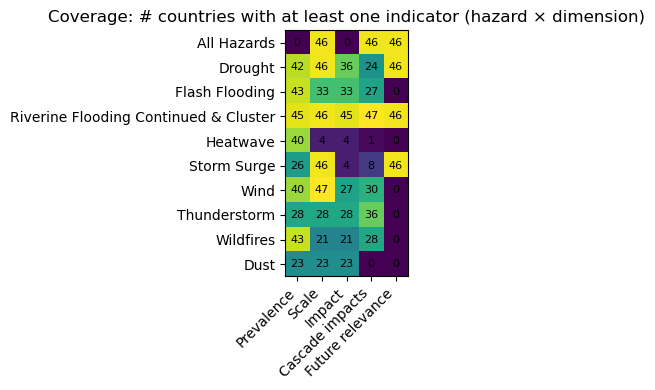

In [11]:
df_scoped = scope_filter(df_long)
plot_coverage_heatmap(df_scoped, "Coverage: # countries with at least one indicator (hazard × dimension)",
                      outpath=os.path.join(FIG_DIR, "coverage_hazard_dimension.png"))


### Indicator inventory (what exists; what is scoring vs QA-only)

In [12]:
meta = make_indicator_metadata(df_scoped)
meta["in_scoring_set"] = meta["indicator_id"].isin(SCORING_INDICATORS)
meta["qa_only_explicit"] = meta["indicator_id"].isin(QA_ONLY_INDICATORS)

display_cols = ["indicator_id","indicator_name","source","dimension","hazard","hazard_applicability","unit_raw","time_window","in_scoring_set","qa_only_explicit"]
display(meta[display_cols].sort_values(["dimension","hazard_applicability","source","indicator_id"]).reset_index(drop=True))


,indicator_id,indicator_name,source,dimension,hazard,hazard_applicability,unit_raw,time_window,in_scoring_set,qa_only_explicit
0,INFORM.DIM.LACK_COPING,INFORM dimension: Lack of Coping Capacity (pro...,INFORM Risk,Cascade impacts,All Hazards,hazard-agnostic,index_0_10,annual_snapshot,True,False
1,DESINVENTAR.EVACUATED_SUM_2000_2024,Evacuated (sum),DesInventar (selected),Cascade impacts,Drought,hazard-specific,count_people,2000-2024,False,True
2,DESINVENTAR.EVACUATED_SUM_2000_2024,Evacuated (sum),DesInventar (selected),Cascade impacts,Riverine Flooding Continued & Cluster,hazard-specific,count_people,2000-2024,False,True
3,DESINVENTAR.EVACUATED_SUM_2000_2024,Evacuated (sum),DesInventar (selected),Cascade impacts,Wind,hazard-specific,count_people,2000-2024,False,True
4,DESINVENTAR.EVACUATED_SUM_2000_2024,Evacuated (sum),DesInventar (selected),Cascade impacts,Thunderstorm,hazard-specific,count_people,2000-2024,False,True
...,...,...,...,...,...,...,...,...,...,...
245,INFORM.HAZEX.TROPICAL_CYCLONE,Hazard & exposure: Tropical Cyclone (proxy for...,INFORM Risk,Scale,Wind,hazard-specific,index_0_10,annual_snapshot,True,False
246,WRI.EI_03,Exposure to coastal flooding (EI_03) — proxy f...,WorldRiskIndex,Scale,Storm Surge,hazard-specific,index_0_100,annual_snapshot,True,False
247,WRI.EI_04,Exposure to riverine flooding (EI_04),WorldRiskIndex,Scale,Riverine Flooding Continued & Cluster,hazard-specific,index_0_100,annual_snapshot,True,False
248,WRI.EI_05,Exposure to cyclones (EI_05) — proxy for wind,WorldRiskIndex,Scale,Wind,hazard-specific,index_0_100,annual_snapshot,True,False


## 4) Run scenarios (default + sensitivity)

In [13]:
results = {}
for s in SCENARIOS.keys():
    results[s] = run_scenario(df_long, pop, s)

print("Scenarios computed:", list(results.keys()))


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:476: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  picked = loss.groupby(["iso3","hazard"], group_keys=False).apply(pick).reset_index(drop=True)
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:231: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("indicator_id", group_keys=False).apply(norm_indicator)
C:\Users

[QA] Missing pop_2024 for 1 country rows. These are excluded from pop-weighted regional aggregation.


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:627: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).reset_index(name="hazard_score")


,iso3,country,region
270,REU,Réunion (France),Southern Africa


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:656: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  popw = g.apply(popw_mean).reset_index(name="region_hazard_score_popw")
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:476: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  picked = loss.groupby(["iso3","hazard"], group_keys=False).apply(pick).reset_index(drop=True)
C:\Users\

...

[QA] Missing pop_2024 for 1 country rows. These are excluded from pop-weighted regional aggregation.


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:533: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["score_01"], x["w"])).reset_index(name="dimension_score")
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:627: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = g.apply(lambda x: weighted_mean(x["dimension_score"], x["dw"])).reset_

,iso3,country,region
270,REU,Réunion (France),Southern Africa


Scenarios computed: ['S_main', 'S_noAgnostic', 'S_gapFillOnly', 'S_futureHazOnly', 'S_overlapArbitration']


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\857826589.py:656: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  popw = g.apply(popw_mean).reset_index(name="region_hazard_score_popw")


In [14]:
s = DEFAULT_SCENARIO

hs = results[s]["hazard_scores"]
scn = results[s]["scoring_norm"]

print("Central Africa — hazard ranking (pop-weighted):")
display(results[s]["region_scores_popw"].query("region=='Central Africa'")
        .sort_values("rank_hazards_within_region_popw"))

print("Storm Surge gating check — Central Africa:")
display(
    hs.query("region=='Central Africa' and hazard=='Storm Surge'")
      .sort_values("hazard_score_raw", ascending=False)
      [["iso3","country","hazard_score_raw","hazard_score","is_exposure_gated","n_presence_hits","presence_indicators"]]
)

print("Riverine Flood gating check — Central Africa:")
display(
    hs.query("region=='Central Africa' and hazard=='Riverine Flooding Continued & Cluster'")
      .sort_values("hazard_score_raw", ascending=False)
      [["iso3","country","hazard_score_raw","hazard_score","is_exposure_gated","n_presence_hits","presence_indicators"]]
)

print("Dust sanity check — ensure it doesn't get wiped out:")
display(
    hs.query("region=='Central Africa' and hazard=='Dust'")
      .sort_values("hazard_score_raw", ascending=False)
      [["iso3","country","hazard_score_raw","hazard_score","is_exposure_gated","n_presence_hits","presence_indicators"]]
      .head(20)
)


Central Africa — hazard ranking (pop-weighted):


,region,hazard,region_hazard_score_popw,rank_hazards_within_region_popw
7,Central Africa,Wildfires,0.519128,1.0
2,Central Africa,Flash Flooding,0.489109,2.0
0,Central Africa,Drought,0.475721,3.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.444451,4.0
6,Central Africa,Thunderstorm,0.406651,5.0
5,Central Africa,Storm Surge,0.397126,6.0
1,Central Africa,Dust,0.338430,7.0
8,Central Africa,Wind,0.310215,8.0
3,Central Africa,Heatwave,0.246255,9.0


Storm Surge gating check — Central Africa:


,iso3,country,hazard_score_raw,hazard_score,is_exposure_gated,n_presence_hits,presence_indicators
131,GAB,Gabon,0.656782,0.656782,False,2,"[INFORM.HAZEX.COASTAL_FLOOD, TH.CF_LEVEL]"
86,COG,Congo (Brazzaville),0.628395,0.628395,False,1,[INFORM.HAZEX.COASTAL_FLOOD]
68,CMR,Cameroon,0.528449,0.528449,False,2,"[INFORM.HAZEX.COASTAL_FLOOD, TH.CF_LEVEL]"
330,STP,São Tomé and Príncipe,0.455556,0.455556,False,1,[INFORM.HAZEX.COASTAL_FLOOD]
77,COD,DR Congo,0.437160,0.437160,False,1,[INFORM.HAZEX.COASTAL_FLOOD]
50,CAF,Central African Rep.,0.368519,0.000000,True,0,NaN
357,TCD,Chad,0.361111,0.000000,True,0,NaN
167,GNQ,Equatorial Guinea,0.313241,0.313241,False,2,"[INFORM.HAZEX.COASTAL_FLOOD, TH.CF_LEVEL]"


Riverine Flood gating check — Central Africa:


,iso3,country,hazard_score_raw,hazard_score,is_exposure_gated,n_presence_hits,presence_indicators
85,COG,Congo (Brazzaville),0.766167,0.766167,False,2,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE..."
356,TCD,Chad,0.615145,0.615145,False,3,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE..."
49,CAF,Central African Rep.,0.491754,0.491754,False,3,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE..."
67,CMR,Cameroon,0.414463,0.414463,False,3,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE..."
76,COD,DR Congo,0.404630,0.404630,False,2,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE..."
166,GNQ,Equatorial Guinea,0.337437,0.337437,False,3,"[DESINVENTAR.EVENTS_PER_YEAR_2000_2024, INFORM..."
130,GAB,Gabon,0.331496,0.331496,False,3,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE..."
329,STP,São Tomé and Príncipe,0.273261,0.273261,False,1,[EM-DAT.EVENTS_PER_YEAR_2000_2024]


Dust sanity check — ensure it doesn't get wiped out:


,iso3,country,hazard_score_raw,hazard_score,is_exposure_gated,n_presence_hits,presence_indicators
353,TCD,Chad,0.955556,0.000000,True,0,NaN
46,CAF,Central African Rep.,0.730886,0.730886,False,1,[EM-DAT.EVENTS_PER_YEAR_2000_2024]
82,COG,Congo (Brazzaville),0.650000,0.000000,True,0,NaN
64,CMR,Cameroon,0.611111,0.000000,True,0,NaN
73,COD,DR Congo,0.506415,0.506415,False,1,[EM-DAT.EVENTS_PER_YEAR_2000_2024]
163,GNQ,Equatorial Guinea,0.455556,0.000000,True,0,NaN
127,GAB,Gabon,0.238889,0.000000,True,0,NaN
326,STP,São Tomé and Príncipe,0.122222,0.000000,True,0,NaN


### Overlap dashboard (plain-language)

**Overlap** = cases where **more than one source** provides the same *construct* (e.g., deaths rate) for the same country & hazard.

If overlap is high, scoring both sources counts the same concept twice.
We compute overlap rates and (optionally) apply **construct arbitration** for affected/deaths/events when overlap ≥ threshold.


,hazard,construct,n_cases,n_overlap,overlap_rate
0,Drought,affected_rate,36,0,0.000000
4,Dust,affected_rate,23,0,0.000000
8,Flash Flooding,affected_rate,33,0,0.000000
12,Heatwave,affected_rate,4,0,0.000000
16,Riverine Flooding Continued & Cluster,affected_rate,45,0,0.000000
20,Storm Surge,affected_rate,4,0,0.000000
24,Thunderstorm,affected_rate,28,0,0.000000
28,Wildfires,affected_rate,21,0,0.000000
32,Wind,affected_rate,26,0,0.000000
1,Drought,deaths_rate,36,0,0.000000


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\1628248841.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


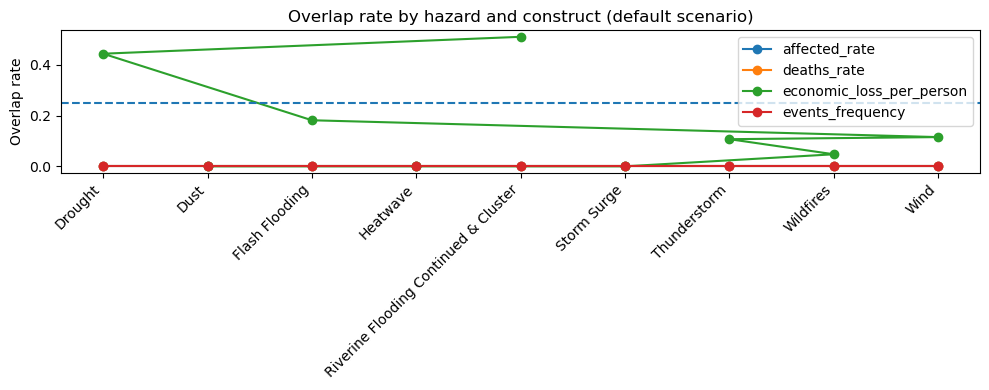

In [15]:
display(results[DEFAULT_SCENARIO]["overlap"])

# simple plot: overlap rate by construct
ov = results[DEFAULT_SCENARIO]["overlap"].copy()
if not ov.empty:
    fig, ax = plt.subplots(figsize=(10,4))
    for construct in ov["construct"].unique():
        sub = ov[ov["construct"].eq(construct)].sort_values("overlap_rate")
        ax.plot(sub["hazard"], sub["overlap_rate"], marker="o", label=construct)
    ax.axhline(OVERLAP_THRESHOLD, linestyle="--")
    ax.set_ylabel("Overlap rate")
    ax.set_title("Overlap rate by hazard and construct (default scenario)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "overlap_rates.png"), dpi=200)
    plt.show()


## 5) Scenario comparison (how rankings change)

We compare the **default scenario** against sensitivity scenarios to show how much decisions matter.


In [16]:
def get_region_ranks(scenario: str) -> pd.DataFrame:
    popw = results[scenario]["region_scores_popw"].copy()
    popw = popw[["region","hazard","region_hazard_score_popw","rank_hazards_within_region_popw"]]
    popw = popw.rename(columns={
        "region_hazard_score_popw": f"score_popw_{scenario}",
        "rank_hazards_within_region_popw": f"rank_popw_{scenario}",
    })
    return popw

base = get_region_ranks(DEFAULT_SCENARIO)
comp = base
for scenario in ["S_noAgnostic","S_gapFillOnly","S_futureHazOnly","S_overlapArbitration"]:
    comp = comp.merge(get_region_ranks(scenario), on=["region","hazard"], how="left")

display(comp.sort_values(["region","rank_popw_"+DEFAULT_SCENARIO]).reset_index(drop=True))


,region,hazard,score_popw_S_main,rank_popw_S_main,score_popw_S_noAgnostic,rank_popw_S_noAgnostic,score_popw_S_gapFillOnly,rank_popw_S_gapFillOnly,score_popw_S_futureHazOnly,rank_popw_S_futureHazOnly,score_popw_S_overlapArbitration,rank_popw_S_overlapArbitration
0,Central Africa,Wildfires,0.519128,1.0,0.395526,3.0,0.479319,1.0,0.428337,3.0,0.519128,1.0
1,Central Africa,Flash Flooding,0.489109,2.0,0.358000,5.0,0.455666,3.0,0.403893,4.0,0.489109,2.0
2,Central Africa,Drought,0.475721,3.0,0.381318,4.0,0.475721,2.0,0.475721,1.0,0.475721,3.0
3,Central Africa,Riverine Flooding Continued & Cluster,0.444451,4.0,0.405085,2.0,0.405085,4.0,0.444451,2.0,0.444451,4.0
4,Central Africa,Thunderstorm,0.406651,5.0,0.296737,6.0,0.372157,6.0,0.328699,6.0,0.406651,5.0
5,Central Africa,Storm Surge,0.397126,6.0,0.244511,8.0,0.397126,5.0,0.397126,5.0,0.397126,6.0
6,Central Africa,Dust,0.338430,7.0,0.245751,7.0,0.338430,7.0,0.272073,7.0,0.338430,7.0
7,Central Africa,Wind,0.310215,8.0,0.209925,9.0,0.283861,8.0,0.242881,8.0,0.310215,8.0
8,Central Africa,Heatwave,0.246255,9.0,0.707112,1.0,0.246255,9.0,0.238876,9.0,0.246255,9.0
9,East Africa,Heatwave,0.569628,1.0,0.475514,5.0,0.569628,1.0,0.498161,3.0,0.569628,1.0


## 6) Country outputs (default scenario)

These are the core country-level ranking outputs used for WP3.


In [17]:
results[DEFAULT_SCENARIO]["regional_contributors"]

,region,hazard,iso3,country,pop_2024,hazard_score,contribution_share
72,Central Africa,Drought,COD,DR Congo,109276265.0,0.477837,0.627106
63,Central Africa,Drought,CMR,Cameroon,29123744.0,0.411982,0.144099
352,Central Africa,Drought,TCD,Chad,20299123.0,0.574934,0.140162
81,Central Africa,Drought,COG,Congo (Brazzaville),6332961.0,0.490901,0.037337
45,Central Africa,Drought,CAF,Central African Rep.,5330690.0,0.571734,0.036603
...,...,...,...,...,...,...,...
26,West Africa,Wind,BEN,Benin,14462724.0,0.000000,0.000000
62,West Africa,Wind,CIV,Côte d'Ivoire,31934230.0,0.000000,0.000000
152,West Africa,Wind,GIN,Guinea,14754785.0,0.000000,0.000000
188,West Africa,Wind,LBR,Liberia,5612817.0,0.000000,0.000000


In [18]:
haz_scores = results[DEFAULT_SCENARIO]["hazard_scores"].copy()
display(haz_scores.sort_values(["hazard","rank_countries_within_hazard"]).head(30))

# Example: one country profile — which hazards rank highest?
example_iso = haz_scores["iso3"].dropna().unique()[0]
profile = haz_scores[haz_scores["iso3"].eq(example_iso)].sort_values("rank_hazards_within_country")
print("Example country:", example_iso, profile["country"].iloc[0])
display(profile[["hazard","hazard_score","rank_hazards_within_country","n_dimensions_used"]])


,iso3,country,region,hazard,hazard_score,n_dimensions_used,n_presence_hits,presence_indicators,presence_dimensions,hazard_score_raw,is_exposure_gated,rank_hazards_within_country,rank_countries_within_hazard
307,SOM,Somalia,East Africa,Drought,0.654842,5,3,"[DESINVENTAR.EVENTS_PER_YEAR_2000_2024, INFORM...","[Prevalence, Scale]",0.654842,False,6.0,1.0
252,NER,Niger,West Africa,Drought,0.645930,5,3,"[DESINVENTAR.EVENTS_PER_YEAR_2000_2024, INFORM...","[Prevalence, Scale]",0.645930,False,3.0,2.0
280,SDN,Sudan,East Africa,Drought,0.630609,5,3,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.630609,False,4.0,3.0
108,ERI,Eritrea,East Africa,Drought,0.594445,5,3,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.594445,False,3.0,4.0
198,MDG,Madagascar,Southern Africa,Drought,0.594014,5,2,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.594014,False,3.0,5.0
352,TCD,Chad,Central Africa,Drought,0.574934,5,3,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.574934,False,6.0,6.0
45,CAF,Central African Rep.,Central Africa,Drought,0.571734,5,3,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.571734,False,6.0,7.0
234,MWI,Malawi,Southern Africa,Drought,0.560146,5,3,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.560146,False,2.0,8.0
289,SEN,Senegal,West Africa,Drought,0.559180,5,3,"[EM-DAT.EVENTS_PER_YEAR_2000_2024, INFORM.HAZE...","[Prevalence, Scale]",0.559180,False,2.0,9.0
144,GIN,Guinea,West Africa,Drought,0.553691,4,2,"[INFORM.HAZEX.DROUGHT, TH.DG_LEVEL]","[Prevalence, Scale]",0.553691,False,5.0,10.0


Example country: AGO Angola


,hazard,hazard_score,rank_hazards_within_country,n_dimensions_used
2,Flash Flooding,0.589360,1.0,5
7,Wildfires,0.568946,2.0,3
5,Storm Surge,0.549375,3.0,4
0,Drought,0.534617,4.0,5
4,Riverine Flooding Continued & Cluster,0.495469,5.0,5
3,Heatwave,0.470655,6.0,3
1,Dust,0.000000,7.0,2
6,Thunderstorm,0.000000,7.0,2
8,Wind,0.000000,7.0,4


## 7) Regional hazard prioritisation (default scenario)

We provide **two** region rankings:
- **Population‑weighted** (intended WP3 regional hazard prioritisation)
- **Unweighted** (sensitivity: each country counts equally)


,region,hazard,region_hazard_score_popw,rank_hazards_within_region_popw
7,Central Africa,Wildfires,0.519128,1.0
2,Central Africa,Flash Flooding,0.489109,2.0
0,Central Africa,Drought,0.475721,3.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.444451,4.0
6,Central Africa,Thunderstorm,0.406651,5.0
5,Central Africa,Storm Surge,0.397126,6.0
1,Central Africa,Dust,0.338430,7.0
8,Central Africa,Wind,0.310215,8.0
3,Central Africa,Heatwave,0.246255,9.0
12,East Africa,Heatwave,0.569628,1.0


,region,hazard,region_hazard_score_unweighted,rank_hazards_within_region_unweighted
4,Central Africa,Riverine Flooding Continued & Cluster,0.454294,1.0
0,Central Africa,Drought,0.387646,2.0
2,Central Africa,Flash Flooding,0.386099,3.0
7,Central Africa,Wildfires,0.385418,4.0
3,Central Africa,Heatwave,0.381909,5.0
5,Central Africa,Storm Surge,0.377448,6.0
6,Central Africa,Thunderstorm,0.299039,7.0
1,Central Africa,Dust,0.154663,8.0
8,Central Africa,Wind,0.128916,9.0
12,East Africa,Heatwave,0.561863,1.0


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\2935765097.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["hazard"], rotation=45, ha="right")


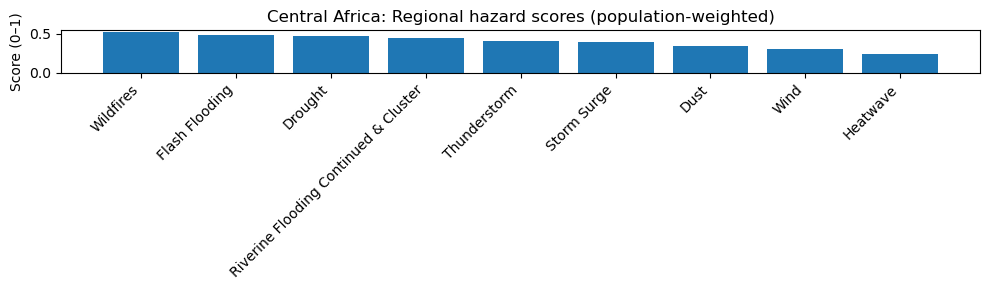

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\2935765097.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["hazard"], rotation=45, ha="right")


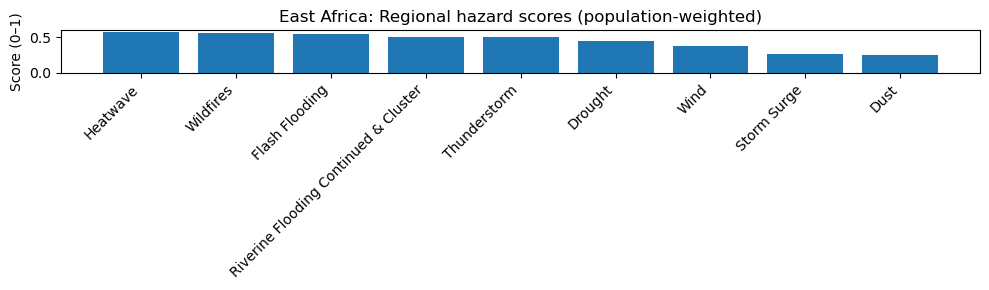

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\2935765097.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["hazard"], rotation=45, ha="right")


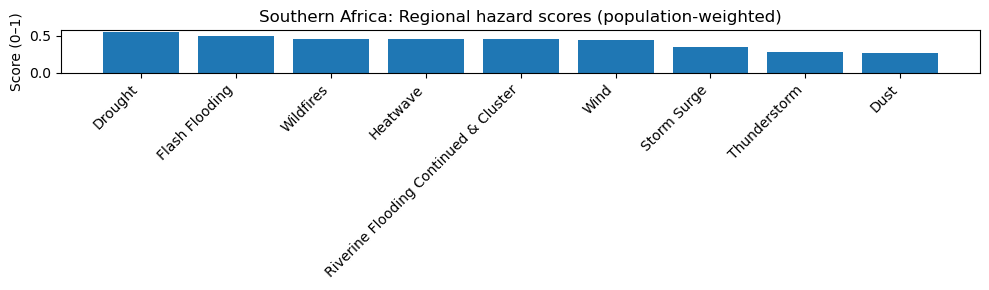

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\2935765097.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["hazard"], rotation=45, ha="right")


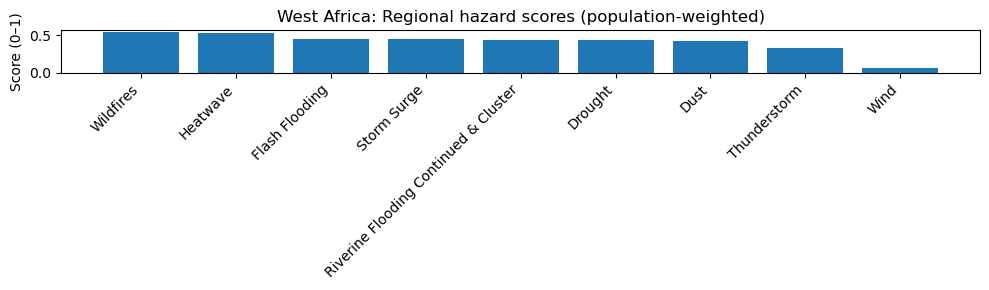

In [19]:
popw = results[DEFAULT_SCENARIO]["region_scores_popw"].copy()
unw = results[DEFAULT_SCENARIO]["region_scores_unweighted"].copy()

display(popw.sort_values(["region","rank_hazards_within_region_popw"]))
display(unw.sort_values(["region","rank_hazards_within_region_unweighted"]))

# Plot: region hazard scores (pop-weighted)
for region in popw["region"].dropna().unique():
    sub = popw[popw["region"].eq(region)].sort_values("region_hazard_score_popw", ascending=False)
    fig, ax = plt.subplots(figsize=(10,3))
    ax.bar(sub["hazard"], sub["region_hazard_score_popw"])
    ax.set_title(f"{region}: Regional hazard scores (population-weighted)")
    ax.set_ylabel("Score (0–1)")
    ax.set_xticklabels(sub["hazard"], rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"region_popw_{re.sub('[^A-Za-z0-9]+','_',region)}.png"), dpi=200)
    plt.show()


### Which countries drive each regional hazard score? (population‑weighted)

This module shows, for each region × hazard, which countries contribute most to the **population‑weighted** regional score.


,region,hazard,iso3,country,pop_2024,hazard_score,contribution_share
72,Central Africa,Drought,COD,DR Congo,109276265.0,0.477837,0.627106
63,Central Africa,Drought,CMR,Cameroon,29123744.0,0.411982,0.144099
352,Central Africa,Drought,TCD,Chad,20299123.0,0.574934,0.140162
81,Central Africa,Drought,COG,Congo (Brazzaville),6332961.0,0.490901,0.037337
45,Central Africa,Drought,CAF,Central African Rep.,5330690.0,0.571734,0.036603
162,Central Africa,Drought,GNQ,Equatorial Guinea,1892516.0,0.360940,0.008204
126,Central Africa,Drought,GAB,Gabon,2538952.0,0.212845,0.006490
325,Central Africa,Drought,STP,São Tomé and Príncipe,235536.0,0.000000,0.000000
73,Central Africa,Dust,COD,DR Congo,109276265.0,0.506415,0.934226
46,Central Africa,Dust,CAF,Central African Rep.,5330690.0,0.730886,0.065774


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\1208632452.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["country"], rotation=45, ha="right")


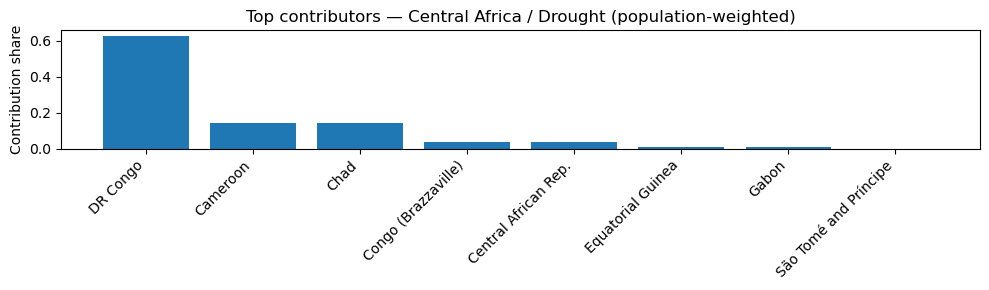

In [20]:
contrib = results[DEFAULT_SCENARIO]["regional_contributors"].copy()
display(contrib.head(50))

# Example plot for one region/hazard
example = contrib.dropna().iloc[0]
reg = example["region"]; haz = example["hazard"]
sub = contrib[(contrib["region"].eq(reg)) & (contrib["hazard"].eq(haz))].sort_values("contribution_share", ascending=False)
fig, ax = plt.subplots(figsize=(10,3))
ax.bar(sub["country"], sub["contribution_share"])
ax.set_title(f"Top contributors — {reg} / {haz} (population-weighted)")
ax.set_ylabel("Contribution share")
ax.set_xticklabels(sub["country"], rotation=45, ha="right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"contributors_{re.sub('[^A-Za-z0-9]+','_',reg)}_{re.sub('[^A-Za-z0-9]+','_',haz)}.png"), dpi=200)
plt.show()


## 8) Explainability: exactly which indicators contributed

For any country × hazard, we can show the dimension score + the indicator scores used to build it.


In [21]:
def explain_country_hazard(iso3: str, hazard: str, scenario: str = DEFAULT_SCENARIO) -> None:
    scoring_norm = results[scenario]["scoring_norm"].copy()
    dim = results[scenario]["dimension_scores"].copy()
    sel = scoring_norm[(scoring_norm["iso3"].eq(iso3)) & (scoring_norm["hazard"].eq(hazard))].copy()
    if sel.empty:
        print("No scoring indicators for", iso3, hazard, "in scenario", scenario)
        return

    print(f"Explainability — {iso3} / {hazard} / {scenario}")
    display(dim[(dim["iso3"].eq(iso3)) & (dim["hazard"].eq(hazard))].sort_values("dimension"))

    display(sel[["dimension","indicator_id","indicator_name","source","value_raw","score_01","hazard_applicability","agnostic_mode"]]
            .sort_values(["dimension","hazard_applicability","indicator_id"])
            .reset_index(drop=True))

# Demo example
iso3_demo = results[DEFAULT_SCENARIO]["hazard_scores"]["iso3"].dropna().unique()[0]
haz_demo = results[DEFAULT_SCENARIO]["hazard_scores"][results[DEFAULT_SCENARIO]["hazard_scores"]["iso3"].eq(iso3_demo)]["hazard"].iloc[0]
explain_country_hazard(iso3_demo, haz_demo)


Explainability — AGO / Drought / S_main


,iso3,country,region,hazard,dimension,dimension_score,n_indicators_used
0,AGO,Angola,Southern Africa,Drought,Cascade impacts,0.510606,2
1,AGO,Angola,Southern Africa,Drought,Future relevance,0.790698,1
2,AGO,Angola,Southern Africa,Drought,Impact,0.369841,3
3,AGO,Angola,Southern Africa,Drought,Prevalence,0.493831,2
4,AGO,Angola,Southern Africa,Drought,Scale,0.508109,5


,dimension,indicator_id,indicator_name,source,value_raw,score_01,hazard_applicability,agnostic_mode
0,Cascade impacts,INFORM.DIM.LACK_COPING,INFORM dimension: Lack of Coping Capacity (pro...,INFORM Risk,6.900000,0.566667,hazard-agnostic,include
1,Cascade impacts,IDMC.DISPLACEMENTS_PER100K_2000_2024_POPREF,IDMC: Disaster internal displacements (per 100...,IDMC (GIDD disasters),19.495406,0.454545,hazard-specific,NaN
2,Future relevance,INFORMCC.CHG_HAZEX.DROUGHT.2050.pessimistic,"Change in Hazard & Exposure: Drought (2050, pe...",INFORM Climate Change,2.100000,0.790698,hazard-specific,NaN
3,Impact,DESINVENTAR.AFFECTED_PER100K_2000_2024,Affected per 100k (Pop2024),DesInventar (selected),1919.492421,0.466667,hazard-specific,NaN
4,Impact,DESINVENTAR.DEATHS_PER100K_2000_2024,Deaths per 100k (Pop2024),DesInventar (selected),0.097662,0.642857,hazard-specific,NaN
5,Impact,EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA_2000_2024,"Total damage, adjusted (USD per person)",EM-DAT (selected),0.000000,0.000000,hazard-specific,NaN
6,Prevalence,DESINVENTAR.EVENTS_PER_YEAR_2000_2024,Events per year (total / 25y),DesInventar (selected),0.680000,0.217391,hazard-specific,NaN
7,Prevalence,TH.DG_LEVEL,ThinkHazard hazard level: Water scarcity,ThinkHazard!,4.000000,0.770270,hazard-specific,NaN
8,Scale,DESINVENTAR.ADMIN_SPREAD_MEAN_ADM2_2000_2024,Mean admin spread (ADM2 count),DesInventar (selected),1.000000,0.500000,hazard-specific,NaN
9,Scale,DESINVENTAR.DURATION_MEAN_DAYS_2000_2024,Mean duration (days),DesInventar (selected),15.352941,0.782609,hazard-specific,NaN


## 9) Export (CSV + Excel workbook)

We export:
- A folder of CSV outputs
- One Excel workbook with multiple sheets (country scores, region scores, contributors, coverage, overlap, scenario comparison, indicator metadata)
- The figures saved under `outputs/wp3_prioritisation/figures/`


In [22]:
import openpyxl
from openpyxl.styles import Font, Alignment, PatternFill
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.worksheet.table import Table, TableStyleInfo

def style_sheet(ws, title: str) -> None:
    ws.freeze_panes = "A2"
    ws.sheet_view.showGridLines = False
    ws["A1"].font = Font(bold=True)
    ws["A1"].alignment = Alignment(horizontal="left", vertical="center")
    ws["A1"].value = title

def write_df(ws, df: pd.DataFrame, start_row: int = 2, start_col: int = 1) -> Tuple[int,int]:
    for r_idx, row in enumerate(dataframe_to_rows(df, index=False, header=True), start=start_row):
        for c_idx, value in enumerate(row, start=start_col):
            ws.cell(row=r_idx, column=c_idx, value=value)
    nrows = len(df) + 1
    ncols = len(df.columns)
    # header style
    header_fill = PatternFill("solid", fgColor="1F4E79")  # dark blue
    header_font = Font(color="FFFFFF", bold=True)
    for c in range(start_col, start_col + ncols):
        cell = ws.cell(row=start_row, column=c)
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    # basic column widths
    for i, col in enumerate(df.columns, start=start_col):
        ws.column_dimensions[openpyxl.utils.get_column_letter(i)].width = max(12, min(40, int(len(str(col))*1.2 + 10)))
    return nrows, ncols

def add_excel_table(ws, nrows: int, ncols: int, start_row: int = 2, start_col: int = 1, name: str = "Table1"):
    end_row = start_row + nrows - 1
    end_col = start_col + ncols - 1
    ref = f"{openpyxl.utils.get_column_letter(start_col)}{start_row}:{openpyxl.utils.get_column_letter(end_col)}{end_row}"
    table = Table(displayName=name, ref=ref)
    style = TableStyleInfo(name="TableStyleMedium9", showRowStripes=True, showColumnStripes=False)
    table.tableStyleInfo = style
    ws.add_table(table)

def excel_safe_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Make a DataFrame safe for openpyxl by converting list/dict/set cells to strings.
    Keeps the table readable in Excel.
    """
    out = df.copy()
    obj_cols = out.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        out[c] = out[c].map(
            lambda v: ", ".join(v) if isinstance(v, (list, tuple, set))
            else (str(v) if isinstance(v, dict) else v)
        )
    return out

def export_excel(results: dict, out_path: str) -> None:
    wb = openpyxl.Workbook()
    # remove default sheet
    wb.remove(wb.active)

    def add_sheet(name: str, title: str, df: pd.DataFrame, table_name: str):
        ws = wb.create_sheet(title=name)
        style_sheet(ws, title)
        df2 = excel_safe_df(df)   # <-- add this line
        nrows, ncols = write_df(ws, df2, start_row=2, start_col=1)
        add_excel_table(ws, nrows=nrows, ncols=ncols, start_row=2, start_col=1, name=table_name)


    # Build key tables for default scenario
    s = DEFAULT_SCENARIO
    add_sheet("Country_Hazard_Scores", "Country hazard scores & ranks (default scenario)", 
              results[s]["hazard_scores"].sort_values(["hazard","rank_countries_within_hazard"]), "CountryHazardScores")
    add_sheet("Country_Dimension_Scores", "Dimension scores (country × hazard × dimension)", 
              results[s]["dimension_scores"].sort_values(["hazard","iso3","dimension"]), "CountryDimensionScores")
    add_sheet("Region_PopWeighted", "Regional hazard prioritisation (population-weighted)", 
              results[s]["region_scores_popw"].sort_values(["region","rank_hazards_within_region_popw"]), "RegionPopW")
    add_sheet("Region_Unweighted", "Regional hazard prioritisation (unweighted)", 
              results[s]["region_scores_unweighted"].sort_values(["region","rank_hazards_within_region_unweighted"]), "RegionUnW")
    add_sheet("Regional_Contributors", "Top contributing countries to each region×hazard (pop-weighted)", 
              results[s]["regional_contributors"].sort_values(["region","hazard","contribution_share"], ascending=[True,True,False]), "RegionalContrib")
    add_sheet("Overlap_QA", "Overlap report (where multiple sources measure the same construct)", 
              results[s]["overlap"], "OverlapQA")
    add_sheet("Indicator_Metadata", "Indicator metadata & applicability (hazard-specific vs hazard-agnostic)", 
              results[s]["meta"].sort_values(["dimension","hazard_applicability","source","indicator_id"]), "IndicatorMeta")

    # Scenario comparison table (region pop-weighted ranks)
    # reuse the comp table from earlier
    comp_df = comp.copy() if "comp" in globals() else pd.DataFrame()
    if not comp_df.empty:
        add_sheet("Scenario_Comparison", "Scenario comparison (region pop-weighted)", comp_df, "ScenarioComp")

    # README tab
    ws = wb.create_sheet(title="README")
    ws.sheet_view.showGridLines = False
    ws["A1"].value = "WP3 Africa Multi-Hazard Prioritisation — Outputs"
    ws["A1"].font = Font(bold=True, size=14)
    ws["A3"].value = "Default scenario:"
    ws["B3"].value = DEFAULT_SCENARIO
    ws["A5"].value = "Notes:"
    ws["A6"].value = "- Scores are 0–1 after percentile normalisation (higher = worse)."
    ws["A7"].value = "- Region_PopWeighted uses WDI SP.POP.TOTL population weights (Pop_2024)."
    ws["A8"].value = "- Overlap_QA explains where multiple sources measured the same construct."
    ws["A10"].value = "Key sources (methods/definitions):"
    ws["A11"].value = "Population definition (WDI SP.POP.TOTL): https://databank.worldbank.org/metadataglossary/world-development-indicators/series/SP.POP.TOTL"
    ws["A12"].value = "Composite indicators handbook (OECD/JRC): https://www.oecd.org/en/publications/handbook-on-constructing-composite-indicators_533411815016.html"
    ws["A13"].value = "ThinkHazard methods: https://gfdrr.github.io/thinkhazardmethods/"
    ws["A14"].value = "EM-DAT economic adjustment: https://doc.emdat.be/docs/protocols/economic-adjustment/"
    ws.column_dimensions["A"].width = 120

    wb.save(out_path)

# Export
excel_path = os.path.join(OUT_DIR, "WP3_Hazard_Prioritisation_Outputs.xlsx")
export_excel(results, excel_path)
print("Excel written:", excel_path)

# CSV exports (default scenario)
def export_csv_tables(results: dict, scenario: str):
    os.makedirs(OUT_DIR, exist_ok=True)
    tables = {
        "indicator_metadata": results[scenario]["meta"],
        "scoring_raw": results[scenario]["scoring_raw"],
        "scoring_norm": results[scenario]["scoring_norm"],
        "qa_only": results[scenario]["qa"],
        "overlap": results[scenario]["overlap"],
        "dimension_scores": results[scenario]["dimension_scores"],
        "hazard_scores": results[scenario]["hazard_scores"],
        "region_scores_popw": results[scenario]["region_scores_popw"],
        "region_scores_unweighted": results[scenario]["region_scores_unweighted"],
        "regional_contributors": results[scenario]["regional_contributors"],
    }
    for name, df in tables.items():
        df.to_csv(os.path.join(OUT_DIR, f"{name}__{scenario}.csv"), index=False)

export_csv_tables(results, DEFAULT_SCENARIO)
print("CSVs written under:", OUT_DIR)


Excel written: C:\pipelines\sewa-multihazar\data\output\wp3_prioritisation\WP3_Hazard_Prioritisation_Outputs.xlsx
CSVs written under: C:\pipelines\sewa-multihazar\data\output\wp3_prioritisation


In [29]:
sc = results[DEFAULT_SCENARIO]["scoring_norm"]

def show_indicator_drivers(iso3, region, hazard, dimension=None):
    q = f"iso3 == @iso3 and region == @region and hazard == @hazard"
    if dimension is not None:
        q += " and dimension == @dimension"
    cols = ["iso3","country","region","hazard","dimension","indicator_id","source",
            "value_raw","score_01","hazard_applicability","agnostic_mode"]
    out = (sc.query(q)[cols]
             .sort_values(["dimension","score_01"], ascending=[True, False]))
    return out

# Example: CAF storm surge drivers
display(show_indicator_drivers("TCD", "Central Africa", "Wildfires"))

,iso3,country,region,hazard,dimension,indicator_id,source,value_raw,score_01,hazard_applicability,agnostic_mode
348,TCD,Chad,Central Africa,Wildfires,Cascade impacts,INFORM.DIM.LACK_COPING,INFORM Risk,8.600000,0.955556,hazard-agnostic,include
139,TCD,Chad,Central Africa,Wildfires,Cascade impacts,IDMC.DISPLACEMENTS_PER100K_2000_2024_POPREF,IDMC (GIDD disasters),1.867076,0.318182,hazard-specific,NaN
210,TCD,Chad,Central Africa,Wildfires,Future relevance,INFORMCC.RISK_INDEX.2050.pessimistic,INFORM Climate Change,7.900000,0.955556,hazard-agnostic,gapfill_only
24,TCD,Chad,Central Africa,Wildfires,Prevalence,TH.WF_LEVEL,ThinkHazard!,4.000000,0.551282,hazard-specific,NaN


In [24]:
sc2 = results[DEFAULT_SCENARIO]["scoring_norm"].copy()

# count hazard-specific vs agnostic indicators per iso3×hazard
mix = (sc2.groupby(["iso3","hazard"])
          .agg(
              n_ind=("indicator_id","nunique"),
              n_hazard_specific=("hazard_applicability", lambda s: (s=="hazard-specific").sum()),
              n_hazard_agnostic=("hazard_applicability", lambda s: (s=="hazard-agnostic").sum()),
          )
          .reset_index())

mix["share_agnostic"] = mix["n_hazard_agnostic"] / mix["n_ind"].replace(0, np.nan)

# join to hazard_scores and sort suspicious cases
hs = results[DEFAULT_SCENARIO]["hazard_scores"].merge(mix, on=["iso3","hazard"], how="left")
sus = (hs.query("hazard == 'Storm Surge'")
         .sort_values(["share_agnostic","hazard_score"], ascending=[False, False]))

display(sus[["iso3","country","region","hazard_score","n_ind","share_agnostic"]].head(30))


,iso3,country,region,hazard_score,n_ind,share_agnostic
86,COG,Congo (Brazzaville),Central Africa,0.628395,4,0.25
330,STP,São Tomé and Príncipe,Central Africa,0.455556,4,0.25
77,COD,DR Congo,Central Africa,0.437160,4,0.25
59,CIV,Côte d'Ivoire,West Africa,0.402963,4,0.25
14,BDI,Burundi,East Africa,0.000000,4,0.25
32,BFA,Burkina Faso,West Africa,0.000000,4,0.25
41,BWA,Botswana,Southern Africa,0.000000,4,0.25
50,CAF,Central African Rep.,Central Africa,0.000000,4,0.25
212,MLI,Mali,West Africa,0.000000,4,0.25
257,NER,Niger,West Africa,0.000000,4,0.25


In [26]:
dim = results[DEFAULT_SCENARIO]["dimension_scores"].copy()

# build full grid iso3×hazard×dimension
grid = (
    dim[["iso3","country","region","hazard"]].drop_duplicates()
    .merge(pd.DataFrame({"dimension": DIMENSIONS}), how="cross")
)

dim_full = (
    grid.merge(dim, on=["iso3","country","region","hazard","dimension"], how="left")
)

dim_full["dimension_score"] = dim_full["dimension_score"].fillna(0.0)
dim_full["dw"] = dim_full["dimension"].map(DIM_WEIGHTS).astype(float)

haz0 = (
    dim_full.groupby(["iso3","country","region","hazard"])
    .apply(lambda x: float(np.average(x["dimension_score"], weights=x["dw"])) if x["dw"].sum()>0 else np.nan)
    .reset_index(name="hazard_score_missingDimsAs0")
)

# compare ranks vs current
cur = results[DEFAULT_SCENARIO]["hazard_scores"][["iso3","hazard","hazard_score","rank_hazards_within_country"]].copy()
cmp = cur.merge(haz0, on=["iso3","hazard"], how="left")

cmp["rank_missingDimsAs0"] = cmp.groupby("iso3")["hazard_score_missingDimsAs0"].rank(ascending=False, method="min")
cmp["rank_diff"] = cmp["rank_missingDimsAs0"] - cmp["rank_hazards_within_country"]

display(cmp.sort_values(["iso3","rank_diff"], ascending=[True, False]).head(50))


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\1714560009.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: float(np.average(x["dimension_score"], weights=x["dw"])) if x["dw"].sum()>0 else np.nan)


,iso3,hazard,hazard_score,rank_hazards_within_country,country,region,hazard_score_missingDimsAs0,rank_missingDimsAs0,rank_diff
7,AGO,Wildfires,0.568946,2.0,Angola,Southern Africa,0.341368,5.0,3.0
6,AGO,Thunderstorm,0.000000,7.0,Angola,Southern Africa,0.219899,9.0,2.0
1,AGO,Dust,0.000000,7.0,Angola,Southern Africa,0.231111,8.0,1.0
3,AGO,Heatwave,0.470655,6.0,Angola,Southern Africa,0.282393,7.0,1.0
5,AGO,Storm Surge,0.549375,3.0,Angola,Southern Africa,0.439500,4.0,1.0
2,AGO,Flash Flooding,0.589360,1.0,Angola,Southern Africa,0.589360,1.0,0.0
8,AGO,Wind,0.000000,7.0,Angola,Southern Africa,0.323788,6.0,-1.0
0,AGO,Drought,0.534617,4.0,Angola,Southern Africa,0.534617,2.0,-2.0
4,AGO,Riverine Flooding Continued & Cluster,0.495469,5.0,Angola,Southern Africa,0.495469,3.0,-2.0
16,BDI,Wildfires,0.578879,2.0,Burundi,East Africa,0.347327,6.0,4.0


# Q&A Diagnosis

In [30]:
import numpy as np
import pandas as pd

s = DEFAULT_SCENARIO
sc = results[s]["scoring_norm"].copy()
dim = results[s]["dimension_scores"].copy()
hs = results[s]["hazard_scores"].copy()

# You should already have pop loaded; sanity check:
assert "pop_2024" in pop.columns, "pop must include pop_2024 (WDI SP.POP.TOTL)"


In [31]:
# Define what counts as "Impact evidence"
IMPACT_INDICATORS = {
    "EM-DAT.DEATHS_PER100K_2000_2024",
    "DESINVENTAR.DEATHS_PER100K_2000_2024",
    "EM-DAT.AFFECTED_PER100K_2000_2024",
    "DESINVENTAR.AFFECTED_PER100K_2000_2024",
    "EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA_2000_2024",
    "DESINVENTAR.LOSS_USD_PER_CAPITA_2000_2024",
}

m_impact = (
    sc["indicator_id"].isin(IMPACT_INDICATORS)
    & sc["value_raw"].notna()
    & sc["hazard_applicability"].eq("hazard-specific")
)

impact_ev = (
    sc.loc[m_impact]
      .groupby(["iso3","hazard"])["indicator_id"]
      .nunique()
      .reset_index(name="n_impact_indicators")
)

# Optional: displacement evidence (kept separate)
m_disp = (
    sc["indicator_id"].eq("IDMC.DISPLACEMENTS_PER100K_2000_2024_POPREF")
    & sc["value_raw"].notna()
    & sc["hazard_applicability"].eq("hazard-specific")
)
disp_ev = (
    sc.loc[m_disp]
      .groupby(["iso3","hazard"])["indicator_id"]
      .nunique()
      .reset_index(name="n_displacement_indicators")
)

tmp = (
    hs.merge(pop[["iso3","pop_2024"]], on="iso3", how="left")
      .merge(impact_ev, on=["iso3","hazard"], how="left")
      .merge(disp_ev, on=["iso3","hazard"], how="left")
)

tmp["n_impact_indicators"] = tmp["n_impact_indicators"].fillna(0).astype(int)
tmp["n_displacement_indicators"] = tmp["n_displacement_indicators"].fillna(0).astype(int)
tmp["has_impact_evidence"] = tmp["n_impact_indicators"].gt(0)
tmp["has_displacement_evidence"] = tmp["n_displacement_indicators"].gt(0)

tmp[["iso3","country","region","hazard","hazard_score","is_exposure_gated","n_impact_indicators","n_displacement_indicators"]].head()


,iso3,country,region,hazard,hazard_score,is_exposure_gated,n_impact_indicators,n_displacement_indicators
0,AGO,Angola,Southern Africa,Drought,0.534617,False,3,1
1,AGO,Angola,Southern Africa,Dust,0.000000,True,0,0
2,AGO,Angola,Southern Africa,Flash Flooding,0.589360,False,3,1
3,AGO,Angola,Southern Africa,Heatwave,0.470655,False,0,0
4,AGO,Angola,Southern Africa,Riverine Flooding Continued & Cluster,0.495469,False,3,1


In [32]:
def popw_avg(values, weights):
    m = values.notna() & weights.notna()
    if m.sum() == 0:
        return np.nan
    return float(np.average(values[m].to_numpy(), weights=weights[m].to_numpy()))

rows = []
for (region, hazard), g in tmp.groupby(["region","hazard"]):
    w = g["pop_2024"]
    rows.append({
        "region": region,
        "hazard": hazard,
        "region_hazard_score_popw": popw_avg(g["hazard_score"], w),
        "pop_share_with_impact_evidence": popw_avg(g["has_impact_evidence"].astype(float), w),
        "pop_share_with_displacement_evidence": popw_avg(g["has_displacement_evidence"].astype(float), w),
        "pop_share_gated": popw_avg(g["is_exposure_gated"].astype(float), w),
        "popw_score_if_has_impact": popw_avg(g.loc[g["has_impact_evidence"], "hazard_score"], g.loc[g["has_impact_evidence"], "pop_2024"]),
        "popw_score_if_no_impact": popw_avg(g.loc[~g["has_impact_evidence"], "hazard_score"], g.loc[~g["has_impact_evidence"], "pop_2024"]),
        "n_countries": int(g["iso3"].nunique()),
    })

evidence_region_hazard = pd.DataFrame(rows)

# Attach regional ranks from your official outputs (so we can compare)
rank_popw = results[s]["region_scores_popw"][["region","hazard","rank_hazards_within_region_popw"]].copy()

evidence_region_hazard = (
    evidence_region_hazard.merge(rank_popw, on=["region","hazard"], how="left")
      .sort_values(["region","rank_hazards_within_region_popw"])
)

display(evidence_region_hazard)


,region,hazard,region_hazard_score_popw,pop_share_with_impact_evidence,pop_share_with_displacement_evidence,pop_share_gated,popw_score_if_has_impact,popw_score_if_no_impact,n_countries,rank_hazards_within_region_popw
7,Central Africa,Wildfires,0.519128,0.665598,0.770761,0.037528,0.500172,0.556858,8,1.0
2,Central Africa,Flash Flooding,0.489109,0.937154,0.806943,0.037528,0.510608,0.168523,8,2.0
0,Central Africa,Drought,0.475721,0.937154,0.000000,0.001346,0.481212,0.393851,8,3.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.444451,1.000000,0.989187,0.000000,0.444451,NaN,8,4.0
6,Central Africa,Thunderstorm,0.406651,0.796079,0.951660,0.203921,0.510817,0.000000,8,5.0
5,Central Africa,Storm Surge,0.397126,0.000000,0.000000,0.146431,NaN,0.397126,8,6.0
1,Central Africa,Dust,0.338430,0.654785,0.000000,0.345215,0.516856,0.000000,8,7.0
8,Central Africa,Wind,0.310215,0.649648,0.654785,0.350352,0.477513,0.000000,8,8.0
3,Central Africa,Heatwave,0.246255,0.000000,0.000000,0.661857,NaN,0.246255,8,9.0
12,East Africa,Heatwave,0.569628,0.119695,0.000000,0.000000,0.650574,0.558622,11,1.0


In [33]:
contrib = results[s]["regional_contributors"].copy()
contrib = contrib.merge(tmp[["iso3","hazard","has_impact_evidence","has_displacement_evidence","is_exposure_gated"]].drop_duplicates(),
                        on=["iso3","hazard"], how="left")

# For each region×hazard, what share of the top contributors lack impact evidence?
qa_contrib = (
    contrib.groupby(["region","hazard"])
           .apply(lambda g: pd.Series({
               "top10_contrib_share_no_impact": float(g.loc[~g["has_impact_evidence"], "contribution_share"].sum()),
               "top10_contrib_share_gated": float(g.loc[g["is_exposure_gated"], "contribution_share"].sum()),
               "top10_contrib_share_no_impact_no_disp": float(g.loc[(~g["has_impact_evidence"]) & (~g["has_displacement_evidence"]), "contribution_share"].sum()),
           }))
           .reset_index()
)

qa_contrib = qa_contrib.merge(rank_popw, on=["region","hazard"], how="left").sort_values(["region","rank_hazards_within_region_popw"])
display(qa_contrib)


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\2471284340.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,region,hazard,top10_contrib_share_no_impact,top10_contrib_share_gated,top10_contrib_share_no_impact_no_disp,rank_hazards_within_region_popw
7,Central Africa,Wildfires,0.358706,0.0,0.199069,1.0
2,Central Africa,Flash Flooding,0.021654,0.0,0.021654,2.0
0,Central Africa,Drought,0.052031,0.0,0.052031,3.0
4,Central Africa,Riverine Flooding Continued & Cluster,0.000000,0.0,0.000000,4.0
6,Central Africa,Thunderstorm,0.000000,0.0,0.000000,5.0
5,Central Africa,Storm Surge,1.000000,0.0,1.000000,6.0
1,Central Africa,Dust,0.000000,0.0,0.000000,7.0
8,Central Africa,Wind,0.000000,0.0,0.000000,8.0
3,Central Africa,Heatwave,1.000000,0.0,1.000000,9.0
12,East Africa,Heatwave,0.860935,0.0,0.860935,1.0


In [34]:
FLOOD_COMPLEX = ["Flash Flooding", "Riverine Flooding Continued & Cluster", "Thunderstorm"]

hs_flood = hs[hs["hazard"].isin(FLOOD_COMPLEX)].copy()

# Combine floods per iso3 (validation only):
# Option 1: max (if any flood type is high, flood complex is high)
flood_max = (hs_flood.groupby(["iso3","country","region"])
                    .agg(flood_complex_score=("hazard_score","max"))
                    .reset_index())

# Option 2: mean (more conservative)
flood_mean = (hs_flood.groupby(["iso3","country","region"])
                     .agg(flood_complex_score=("hazard_score","mean"))
                     .reset_index())

def region_popw_from_country_scores(df_country, score_col="flood_complex_score"):
    dfc = df_country.merge(pop[["iso3","pop_2024"]], on="iso3", how="left")
    out = (dfc.groupby("region")
              .apply(lambda g: popw_avg(g[score_col], g["pop_2024"]))
              .reset_index(name="region_score_popw"))
    return out

r_flood_max = region_popw_from_country_scores(flood_max, "flood_complex_score")
r_flood_mean = region_popw_from_country_scores(flood_mean, "flood_complex_score")

r_flood_max["hazard"] = "Flood complex (max of Flash/River/Thunder)"
r_flood_mean["hazard"] = "Flood complex (mean of Flash/River/Thunder)"

validation = pd.concat([r_flood_max, r_flood_mean], ignore_index=True)

# Compare against your current hazards
baseline = results[s]["region_scores_popw"][["region","hazard","region_hazard_score_popw"]].rename(
    columns={"region_hazard_score_popw":"region_score_popw"}
)

compare = pd.concat([baseline, validation], ignore_index=True)
compare = compare.sort_values(["region","region_score_popw"], ascending=[True, False])

display(compare)


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\2302615715.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: popw_avg(g[score_col], g["pop_2024"]))
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_23236\2302615715.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: popw_avg(g[score_col], g["pop_2024"]))


,region,hazard,region_score_popw
36,Central Africa,Flood complex (max of Flash/River/Thunder),0.519537
7,Central Africa,Wildfires,0.519128
2,Central Africa,Flash Flooding,0.489109
0,Central Africa,Drought,0.475721
40,Central Africa,Flood complex (mean of Flash/River/Thunder),0.446737
4,Central Africa,Riverine Flooding Continued & Cluster,0.444451
6,Central Africa,Thunderstorm,0.406651
5,Central Africa,Storm Surge,0.397126
1,Central Africa,Dust,0.338430
8,Central Africa,Wind,0.310215


In [35]:
sc_nonnull = sc[sc["score_01"].notna()].copy()

cov_country_hazard = (
    sc_nonnull.groupby(["iso3","hazard"])
      .agg(
          n_rows=("indicator_id","size"),
          n_indicators=("indicator_id","nunique"),
          n_dim=("dimension","nunique"),
          share_agnostic=("hazard_applicability", lambda s: float((s=="hazard-agnostic").mean()) if len(s) else np.nan),
          share_TH=("indicator_id", lambda s: float(pd.Series(s).astype(str).str.startswith("TH.").mean()) if len(s) else np.nan),
          has_impact=("dimension", lambda s: bool((pd.Series(s)=="Impact").any())),
          has_prevalence=("dimension", lambda s: bool((pd.Series(s)=="Prevalence").any())),
          has_scale=("dimension", lambda s: bool((pd.Series(s)=="Scale").any())),
      )
      .reset_index()
)

cov_country_hazard = cov_country_hazard.merge(hs[["iso3","hazard","hazard_score"]], on=["iso3","hazard"], how="left")
cov_country_hazard = cov_country_hazard.merge(pop[["iso3","pop_2024"]], on="iso3", how="left")
cov_country_hazard = cov_country_hazard.merge(hs[["iso3","hazard","region"]].drop_duplicates(), on=["iso3","hazard"], how="left")

def popw_share_bool(g, col):
    return popw_avg(g[col].astype(float), g["pop_2024"])

def popw_mean(g, col):
    return popw_avg(g[col], g["pop_2024"])

rows=[]
for (region, hazard), g in cov_country_hazard.groupby(["region","hazard"]):
    rows.append({
        "region": region,
        "hazard": hazard,
        "popw_n_indicators": popw_mean(g, "n_indicators"),
        "popw_share_agnostic": popw_mean(g, "share_agnostic"),
        "popw_share_TH": popw_mean(g, "share_TH"),
        "pop_share_has_impact": popw_share_bool(g, "has_impact"),
        "pop_share_has_prev": popw_share_bool(g, "has_prevalence"),
        "pop_share_has_scale": popw_share_bool(g, "has_scale"),
        "region_hazard_score_popw_recomputed": popw_mean(g, "hazard_score"),
    })

cov_region_hazard = pd.DataFrame(rows).merge(rank_popw, on=["region","hazard"], how="left")
cov_region_hazard = cov_region_hazard.sort_values(["region","rank_hazards_within_region_popw"])

display(cov_region_hazard)


,region,hazard,popw_n_indicators,popw_share_agnostic,popw_share_TH,pop_share_has_impact,pop_share_has_prev,pop_share_has_scale,region_hazard_score_popw_recomputed,rank_hazards_within_region_popw
7,Central Africa,Wildfires,7.102491,0.363349,0.093540,0.665598,0.962472,0.665598,0.519128,1.0
2,Central Africa,Flash Flooding,9.080832,0.240988,0.038391,0.937154,0.962472,0.937154,0.489109,2.0
0,Central Africa,Drought,9.306280,0.112531,0.033779,0.937154,0.962472,1.000000,0.475721,3.0
4,Central Africa,Riverine Flooding Continued & Cluster,12.087278,0.082859,0.027420,1.000000,1.000000,1.000000,0.444451,4.0
6,Central Africa,Thunderstorm,7.728134,0.325663,0.000000,0.796079,0.796079,0.796079,0.406651,5.0
5,Central Africa,Storm Surge,4.191711,0.240414,0.038342,0.000000,0.191711,1.000000,0.397126,6.0
1,Central Africa,Dust,5.273927,0.532296,0.000000,0.654785,0.654785,0.654785,0.338430,7.0
8,Central Africa,Wind,8.744384,0.273609,0.035580,0.649648,0.816041,1.000000,0.310215,8.0
3,Central Africa,Heatwave,2.338143,0.887286,0.112714,0.000000,0.338143,0.000000,0.246255,9.0
12,East Africa,Heatwave,3.837867,0.610809,0.305404,0.119695,1.000000,0.119695,0.569628,1.0


In [36]:
def show_region_hazard_diagnosis(region, hazard, top_n=12):
    c = results[s]["regional_contributors"].copy()
    c = c[(c["region"]==region) & (c["hazard"]==hazard)].copy()
    c = c.merge(cov_country_hazard[["iso3","hazard","n_indicators","share_TH","share_agnostic","has_impact","has_prevalence","has_scale"]],
                on=["iso3","hazard"], how="left")
    return c.sort_values("contribution_share", ascending=False).head(top_n)

display(show_region_hazard_diagnosis("Central Africa", "Wildfires", top_n=15))
display(show_region_hazard_diagnosis("West Africa", "Wildfires", top_n=15))


,region,hazard,iso3,country,pop_2024,hazard_score,contribution_share,n_indicators,share_TH,share_agnostic,has_impact,has_prevalence,has_scale
0,Central Africa,Wildfires,COD,DR Congo,109276265.0,0.495879,0.596370,9,0.000000,0.222222,True,True,True
1,Central Africa,Wildfires,CMR,Cameroon,29123744.0,0.591168,0.189484,3,0.333333,0.666667,False,True,False
2,Central Africa,Wildfires,TCD,Chad,20299123.0,0.714569,0.159638,4,0.250000,0.500000,False,True,False
3,Central Africa,Wildfires,CAF,Central African Rep.,5330690.0,0.670530,0.039338,10,0.100000,0.200000,True,True,True
4,Central Africa,Wildfires,GAB,Gabon,2538952.0,0.343020,0.009585,3,0.333333,0.666667,False,True,False
5,Central Africa,Wildfires,GNQ,Equatorial Guinea,1892516.0,0.268175,0.005586,9,0.111111,0.222222,True,True,True
6,Central Africa,Wildfires,COG,Congo (Brazzaville),6332961.0,0.000000,0.000000,2,0.000000,1.000000,False,False,False
7,Central Africa,Wildfires,STP,São Tomé and Príncipe,235536.0,0.000000,0.000000,2,0.000000,1.000000,False,False,False


,region,hazard,iso3,country,pop_2024,hazard_score,contribution_share,n_indicators,share_TH,share_agnostic,has_impact,has_prevalence,has_scale
0,West Africa,Wildfires,NGA,Nigeria,232679478.0,0.665242,0.638018,3,0.333333,0.666667,False,True,False
1,West Africa,Wildfires,NER,Niger,27032412.0,0.669863,0.074639,9,0.111111,0.222222,True,True,True
2,West Africa,Wildfires,BFA,Burkina Faso,23548781.0,0.650427,0.063134,3,0.333333,0.666667,False,True,False
3,West Africa,Wildfires,GHA,Ghana,34427414.0,0.350608,0.049753,9,0.111111,0.222222,True,True,True
4,West Africa,Wildfires,MLI,Mali,24478595.0,0.439524,0.044347,9,0.111111,0.222222,True,True,True
5,West Africa,Wildfires,GIN,Guinea,14754785.0,0.472451,0.028733,10,0.100000,0.200000,True,True,True
6,West Africa,Wildfires,BEN,Benin,14462724.0,0.412222,0.024574,10,0.100000,0.200000,True,True,True
7,West Africa,Wildfires,SEN,Senegal,18501984.0,0.321843,0.024545,9,0.111111,0.222222,True,True,True
8,West Africa,Wildfires,TGO,Togo,9515236.0,0.439316,0.017230,3,0.333333,0.666667,False,True,False
9,West Africa,Wildfires,SLE,Sierra Leone,8642022.0,0.433301,0.015435,10,0.100000,0.200000,True,True,True


## Done ✅

You now have:
- A transparent, scenario-driven prioritisation workflow
- Country + regional hazard prioritisation (pop-weighted and unweighted)
- Overlap diagnostics + optional arbitration
- Per-hazard hazard-agnostic switches
- Full explainability (which indicators contributed)

Next steps:
- Review the indicator lock list (`SCORING_INDICATORS`) and hazard-agnostic matrix (`AGNOSTIC_PER_HAZARD`)
- Adjust weights if needed
- Re-run scenarios and re-export the Excel deliverable
